<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg", align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.891 · Aprendizaje automático · PEC2</p>
<p style="margin: 0; text-align:right;">2025-1 · Máster universitario en Ciencia de datos (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicación</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>


# PEC 2: Métodos no supervisados

En esta práctica exploraremos el <strong>aprendizaje no supervisado</strong> con un caso real: el análisis y agrupamiento de miles de recetas. A partir de datos textuales y de ingredientes, crearemos distintas representaciones (desde <strong><em>embeddings</em> semánticos de modelos de lenguaje</strong> hasta vectores <strong><em>one-hot</em></strong>) para descubrir patrones sin etiquetas. Usaremos <strong>UMAP</strong> para reducir dimensionalidad y distintas técnicas de <strong><em>clustering</em></strong> para segmentar, observando cómo la elección de representación y métrica de distancia condiciona las estructuras detectadas y su interpretación.

La PEC consta de dos ejercicios:

 - **Clustering con distintas estrategias**: k-means y regla del codo, basadas en densidad y jerárquicas.
 - **Aplicación**: clustering y reducción de dimensionalidad culinaria, distintas maneras de descubrir grupos de recetas en base a sus metadatos.

**Importante**: cada uno de los ejercicios puede suponer varios minutos de ejecución, por lo que la entrega debe hacerse en formato notebook y en formato html, donde se vea el código, los resultados y comentarios de cada ejercicio. Se puede exportar el notebook a html desde el menú File → Download as → HTML.

**Importante**: existe un tipo de celda especial para albergar texto. Este tipo de celda os será muy útil para responder a las diferentes preguntas teóricas planteadas a lo largo de cada PEC. Para cambiar el tipo de celda a este tipo, elegid en el menú: Cell → Cell Type → Markdown.

**Importante**: la solución planteada no debe utilizar métodos, funciones o parámetros declarados "deprecated" en futuras versiones.

**Importante**: es conveniente que utilicéis una semilla con un valor fijo (en este Notebook se os propone la variable seed inicializada a 100) en todos aquellos métodos o funciones que contengan alguna componente aleatoria para aseguraros de que obtendréis siempre el mismo resultado en las distintas ejecuciones de vuestro código.

**Importante**: si la ejecución de una celda toma más de 20 minutos puedes reducir el número de filas del dataframe para agilizar el proceso.

**Importante**: no olvidéis poner vuestro nombre y apellidos en la siguiente celda.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Nombre y apellidos: Lucas Zamora Vera</strong>
</div>

---

Para ello vamos a necesitar las siguientes librerías:

In [1]:
import ast
from collections import Counter
import random

import hdbscan
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform, cdist
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sentence_transformers import SentenceTransformer
from sklearn import cluster
from sklearn.cluster import KMeans, DBSCAN, MeanShift, estimate_bandwidth, AgglomerativeClustering
from sklearn import datasets
from sklearn import manifold
from sklearn.metrics import silhouette_score, pairwise_distances
from sklearn.metrics.pairwise import cosine_distances, euclidean_distances
from sklearn.preprocessing import MultiLabelBinarizer
import tqdm
import umap.umap_ as umap

## 1. Métodos de *clustering* (4 puntos)

Este ejercicio trata de explorar distintas técnicas de agrupamiento ajustándolas a distintos conjuntos de datos.

El objetivo es doble: entender la influencia de los parámetros en su comportamiento, y conocer sus limitaciones en la búsqueda de estructuras de datos.

### Generación de los conjuntos de datos

In [2]:
X_blobs, y_blobs = datasets.make_blobs(n_samples=1000, n_features=2, centers=4, cluster_std=1.6, random_state=42)
X_moons, y_moons = datasets.make_moons(n_samples=1000, noise=.07, random_state=42)
X_circles, y_circles = datasets.make_circles(n_samples=1000, factor=.5, noise=.05, random_state=42)

Cada dataset tiene 2 variables: una variable *X* que contiene 2 features (columnas) y tantas filas como muestras. Y una variable *y* que alberga las etiquetas que identifican cada cluster.

A lo largo del ejercicio no se usará la variable *y* (sólo con el objetivo de visualizar). El objetivo es a través de los distintos modelos de *clustering* conseguir encontrar las estructuras descritas por las variables *y*.

/var/folders/_0/0mvwr6n91z3gb38kx0gvn8t00000gn/T/ipykernel_76819/339150881.py:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X[:,0], X[:,1], s=15, c='gray', alpha=.3, cmap='jet')


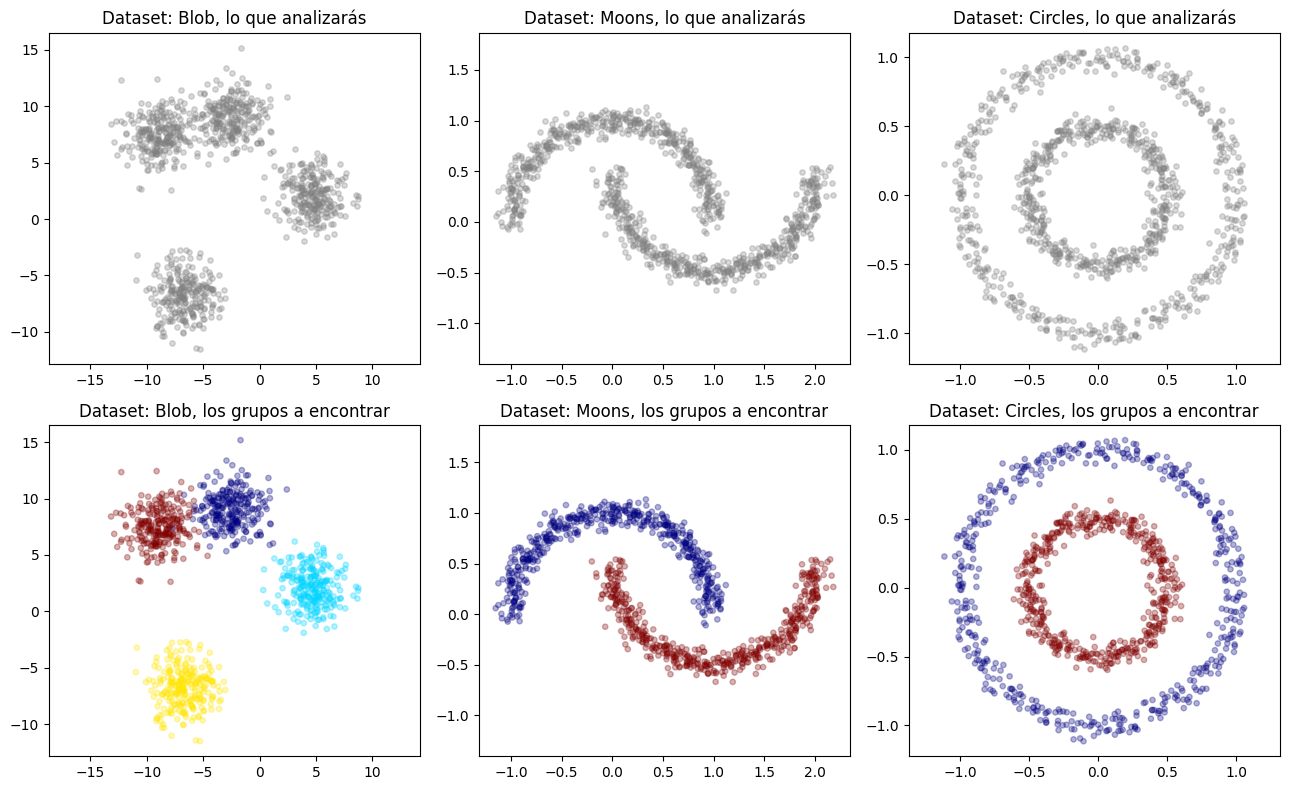

In [3]:
fig, axis = plt.subplots(2, 3, figsize=(13, 8))
for i, (X, y, ax, name) in enumerate(zip([X_blobs, X_moons, X_circles] * 2,
                                         [None] * 3 + [y_blobs, y_moons, y_circles],
                                         axis.reshape(-1),
                                         ['Blob', 'Moons', 'Circles'] * 2)):
    ax.set_title('Dataset: {}, '.format(name) + ('lo que analizarás' if i < 3 else 'los grupos a encontrar'))
    if y is not None:
        ax.scatter(X[:,0], X[:,1], s=15, c=y, alpha=.3, cmap='jet')
    else:
        ax.scatter(X[:,0], X[:,1], s=15, c='gray', alpha=.3, cmap='jet')
    ax.axis('equal')
plt.tight_layout()

### 1 a. K-means

En este apartado se pide probar el algoritmo *k-means* sobre los tres datasets presentados anteriormente ajustando con los parámetros adecuados y analizar sus resultados.

In [4]:
X, y = X_blobs, y_blobs

Para estimar el número de clusters a detectar por *k-means*. Una técnica para estimar $k$ es, como se explica en la teoría:
> Los criterios anteriores (minimización de distancias intra grupo o maximización de distancias inter grupo) pueden usarse para establecer un valor adecuado para el parámetro k. Valores k para los que ya no se consiguen mejoras significativas en la homogeneidad interna de los segmentos o la heterogeneidad entre segmentos distintos, deberían descartarse.

Lo que popularmente se conocer como *regla del codo*.

Primero es necesario calcular la suma de los errores cuadráticos ([*SSE*](https://bl.ocks.org/rpgove/0060ff3b656618e9136b)) que consiste en la suma de todos los errores (distancia de cada punto a su centroide asignado) al cuadrado.

$$SSE = \sum_{i=1}^{K} \sum_{x \in C_i} euclidean(x, c_i)^2$$

Donde $K$ es el número de clusters a buscar por *k-means*, $x \in C_i$ son los puntos que pertenecen a i-ésimo cluster, $c_i$ es el centroide del cluster $C_i$ (al que pertenece el punto $x$), y $euclidean$ es la [distancia euclídea](https://en.wikipedia.org/wiki/Euclidean_distance).

Este procedimiento realizado para cada posible valor $k$, resulta en una función monótona decreciente, donde el eje $x$ representa los distintos valores de $k$, y el eje $y$ el $SSE$. Intuitivamente se podrá observar un significativo descenso del error, que indicará el valor idóneo de $k$.

**Se pide realizar la representación gráfica de la regla del codo junto a su interpretación, utilizando la librería ```matplotlib``` y la implementación en scikit-learn de [*k-means*](http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html).**

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Cálculo y visualización de la regla del codo en el dataset Blobs.
</div>

In [5]:
sse = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

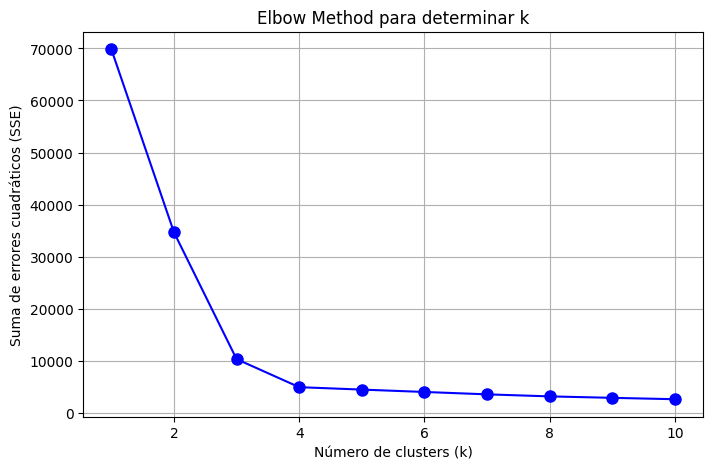

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(K, sse, "bo-", markersize=8)
plt.xlabel("Número de clusters (k)")
plt.ylabel("Suma de errores cuadráticos (SSE)")
plt.title("Elbow Method para determinar k")
plt.grid(True)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué se interpreta en la gráfica? ¿Cómo podría mejorarse la elección de $k$?.  
</div>

Entre los valores 1 y 3 de K se observa una disminución muy fuerte del valor de SEE, a partir de K = 4 esta disminución se estabiliza, por lo que visualmente k = 3 o K = 4 podrían ser valores óptimos del número de clusters.  

Ya que el método del codo puede ser subjetivo ya que se mide visualmente, este puede completarse con la métrica del coeficiente de silueta (Silhoutte Score), que mide como de buena es la separación entre clusters.   
Implementandolo obtenemos el siguiente resultado:



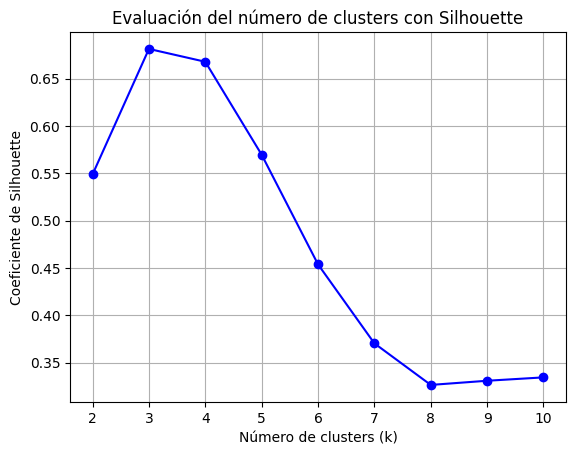

In [7]:
silhouette_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    silhouette_scores.append(silhouette_score(X, labels))

plt.plot(K, silhouette_scores, "bo-")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Coeficiente de Silhouette")
plt.title("Evaluación del número de clusters con Silhouette")
plt.grid(True)
plt.show()

Al observar El gráfico del Silhoutte Score en conjunto con el del método del codo, confirmamos que el número de clusters óptimos está entre 3 y 4, lo que se ajusta a los 4 grupos que el enunciado nos pide encontrar.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Cálculo y visualización de los grupos en el dataset Blobs.
</div>

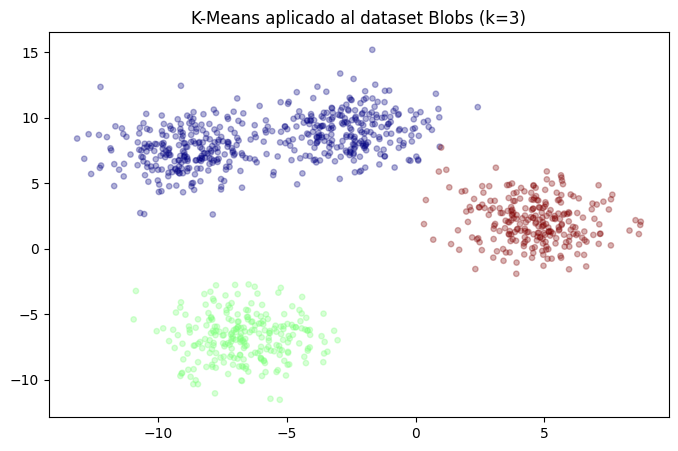

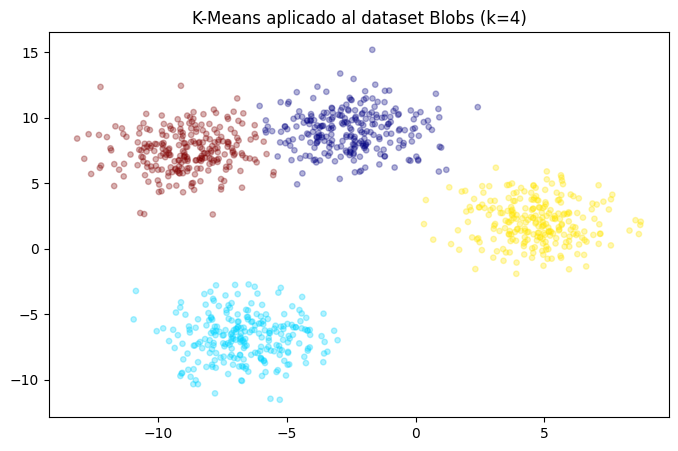

In [8]:
# Prueba con k = 3 y k = 4
valores_k = [3, 4]

for k in valores_k:
    # Aplicar K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    y_kmeans = kmeans.fit_predict(X)

    # Visualización de los clusters
    plt.figure(figsize=(8, 5))
    plt.scatter(X[:, 0], X[:, 1],  s=  15, c = y_kmeans, alpha = 0.3, cmap = "jet")

    plt.title(f"K-Means aplicado al dataset Blobs (k={k})")

    plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué ha sucedido? Explica los motivos por los que crees que se ha producido ese resultado.  
</div>

Cuando algunos clusters están próximos entre sí (como los dos de la parte superior), un valor de K pequeño hace que el algoritmo fusione los dos grupos.  
Con k = 4 se observa una segmentación más coherente con la estructura de los datos, y se alinea con el ejemplo proporcionado en el enunciado.  
Por lo tanto k = 4 es el válor óptimo para lograr la segmentación deseada.

In [9]:
X, y = X_moons, y_moons

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Cálculo y visualización de la regla del codo en el dataset Moons.
</div>

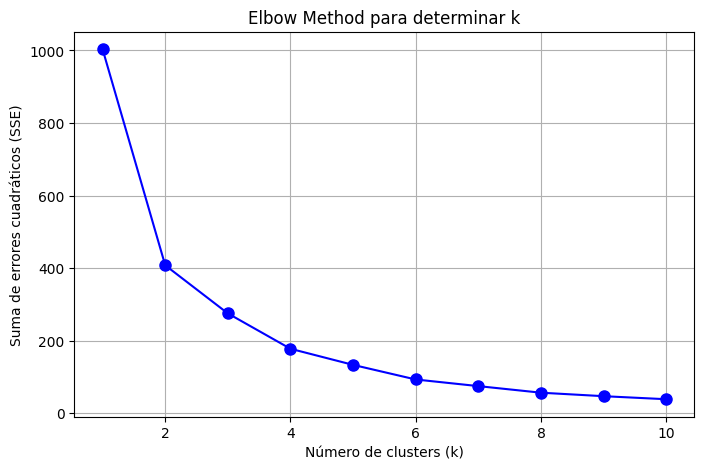

In [10]:
sse = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, sse, "bo-", markersize=8)
plt.xlabel("Número de clusters (k)")
plt.ylabel("Suma de errores cuadráticos (SSE)")
plt.title("Elbow Method para determinar k")
plt.grid(True)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué se interpreta en la gráfica? ¿Cómo podría mejorarse la elección de $k$?.  
</div>

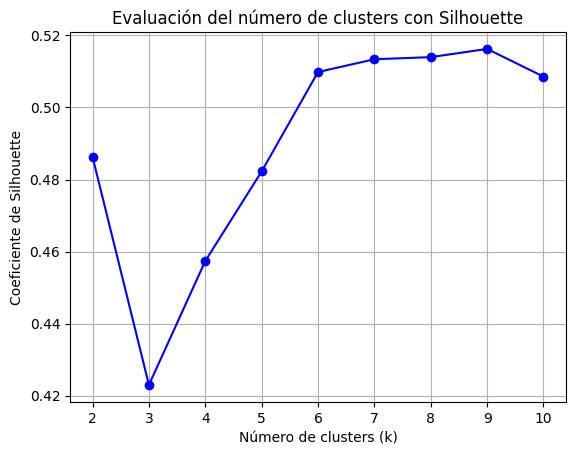

In [11]:
silhouette_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    silhouette_scores.append(silhouette_score(X, labels))

plt.plot(K, silhouette_scores, "bo-")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Coeficiente de Silhouette")
plt.title("Evaluación del número de clusters con Silhouette")
plt.grid(True)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Cálculo y visualización de los grupos en el dataset Moons.
</div>

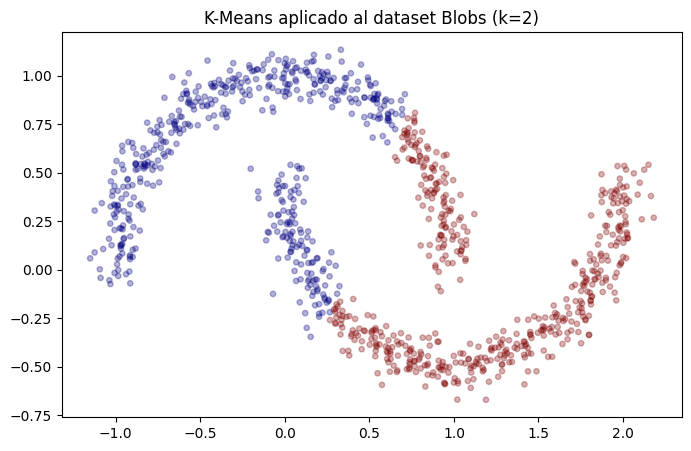

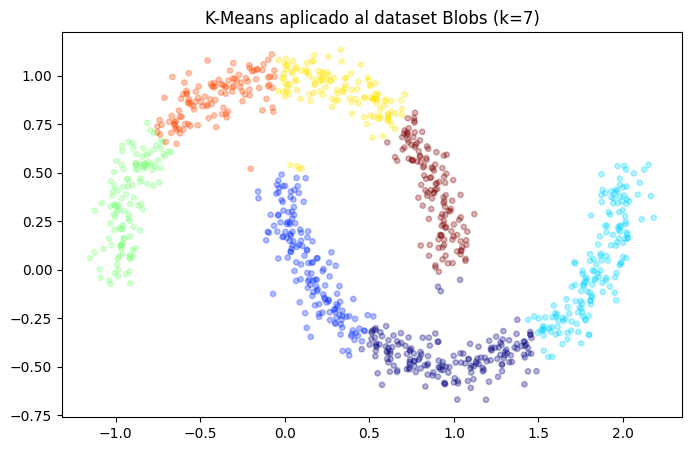

In [12]:
# Prueba con k = 3 y k = 4
valores_k = [2, 7]

for k in valores_k:
    # Aplicar K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    y_kmeans = kmeans.fit_predict(X)

    # Visualización de los clusters
    plt.figure(figsize=(8, 5))
    plt.scatter(X[:, 0], X[:, 1],  s=  15, c = y_kmeans, alpha = 0.3, cmap = "jet")

    plt.title(f"K-Means aplicado al dataset Blobs (k={k})")

    plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué ha sucedido? Explica los motivos por los que crees que se ha producido ese resultado.  
</div>

In [13]:
X, y = X_circles, y_circles

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Cálculo y visualización de la regla del codo en el dataset Circles.
</div>

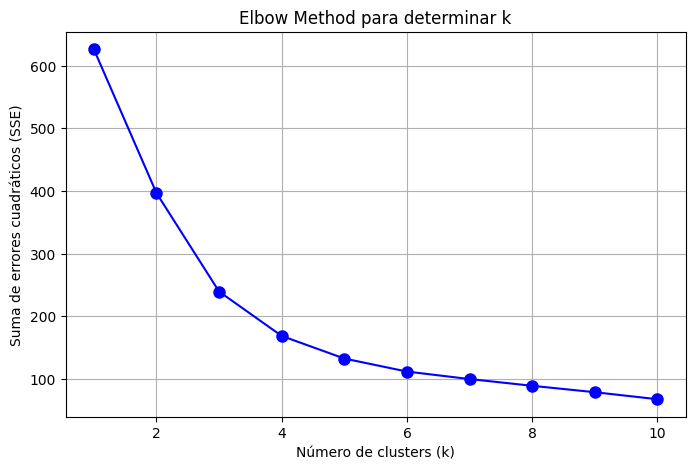

In [14]:
sse = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, sse, "bo-", markersize=8)
plt.xlabel("Número de clusters (k)")
plt.ylabel("Suma de errores cuadráticos (SSE)")
plt.title("Elbow Method para determinar k")
plt.grid(True)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué se interpreta en la gráfica? ¿Cómo podría mejorarse la elección de $k$?.  
</div>

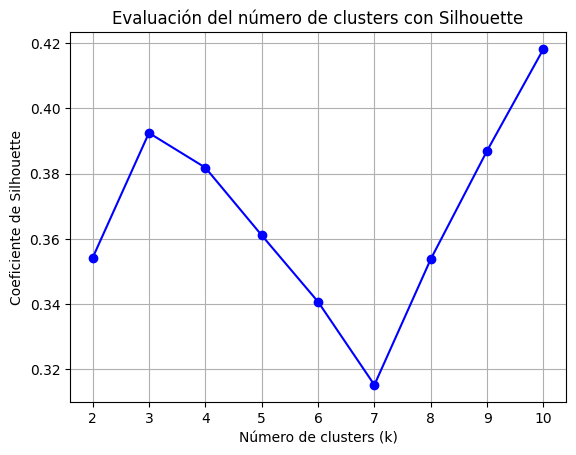

In [15]:
silhouette_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    silhouette_scores.append(silhouette_score(X, labels))

plt.plot(K, silhouette_scores, "bo-")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Coeficiente de Silhouette")
plt.title("Evaluación del número de clusters con Silhouette")
plt.grid(True)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Cálculo y visualización de los grupos en el dataset Circles.
</div>

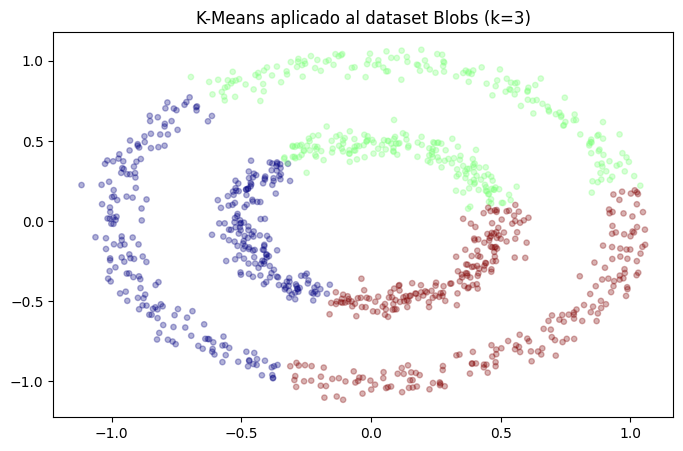

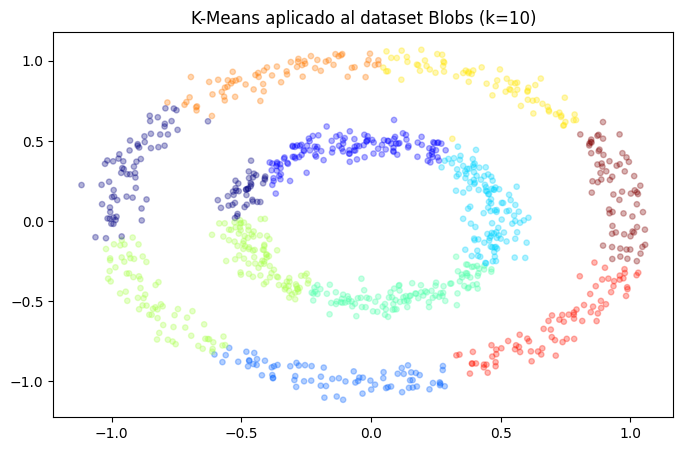

In [16]:
# Prueba con k = 3 y k = 4
valores_k = [3, 10]

for k in valores_k:
    # Aplicar K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    y_kmeans = kmeans.fit_predict(X)

    # Visualización de los clusters
    plt.figure(figsize=(8, 5))
    plt.scatter(X[:, 0], X[:, 1],  s=  15, c = y_kmeans, alpha = 0.3, cmap = "jet")

    plt.title(f"K-Means aplicado al dataset Blobs (k={k})")

    plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué ha sucedido? Explica los motivos por los que crees que se ha producido ese resultado.  
</div>

### 1 b. Algoritmos basados en densidad: DBScan

En este apartado se pide aplicar clustering por densidad como [DBSCAN](https://en.wikipedia.org/wiki/DBSCAN) a los datasets anteriores para detectar los grupos subyacentes.

In [17]:
X, y = X_blobs, y_blobs

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Prueba la implementación de <a href="http://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html">DBSCAN en scikit-learn</a> jugando con los parámetros <i>eps</i> y <i>min_samples</i> para encontrar los grupos (y <i>outliers</i>) del dataset Blobs.
</div>

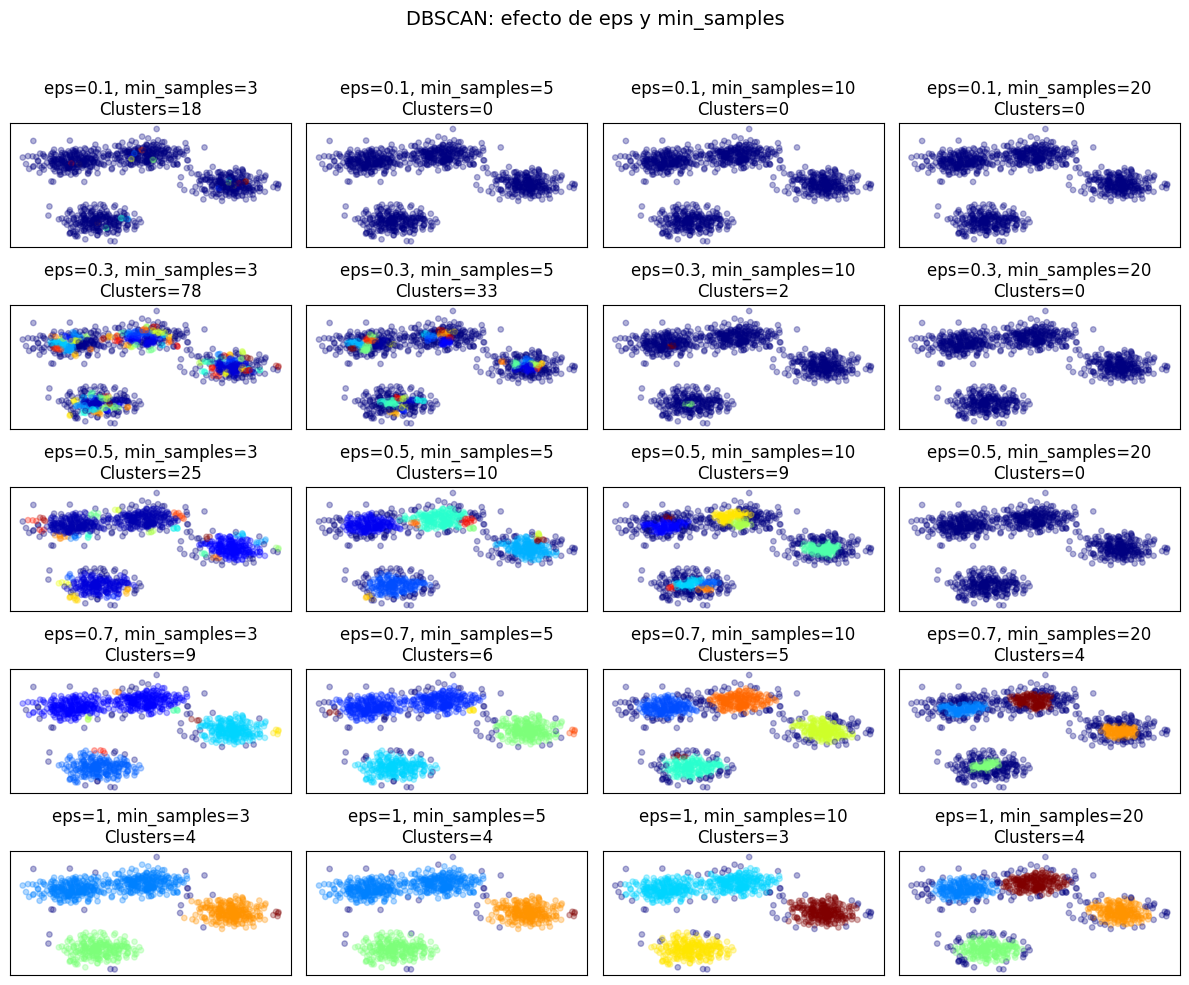

In [18]:
eps_values = [0.1, 0.3, 0.5, 0.7, 1]
min_samples_values = [3, 5, 10, 20]

fig, axes = plt.subplots(len(eps_values), len(min_samples_values), figsize=(12, 10))
fig.suptitle("DBSCAN: efecto de eps y min_samples", fontsize=14)

for i, eps in enumerate(eps_values):
    for j, min_s in enumerate(min_samples_values):
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        axes[i, j].scatter(X[:, 0], X[:, 1], c=labels, cmap="jet", s=15, alpha=0.3)
        axes[i, j].set_title(f"eps={eps}, min_samples={min_s}\nClusters={n_clusters}")
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué ha sucedido? Explica los motivos por los que crees que se ha producido ese resultado.  
</div>

In [19]:
X, y = X_moons, y_moons

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Prueba la implementación de DBSCAN jugando con los parámetros <i>eps</i> y <i>min_samples</i> para encontrar los grupos (y <i>outliers</i>) del dataset Moons.
</div>

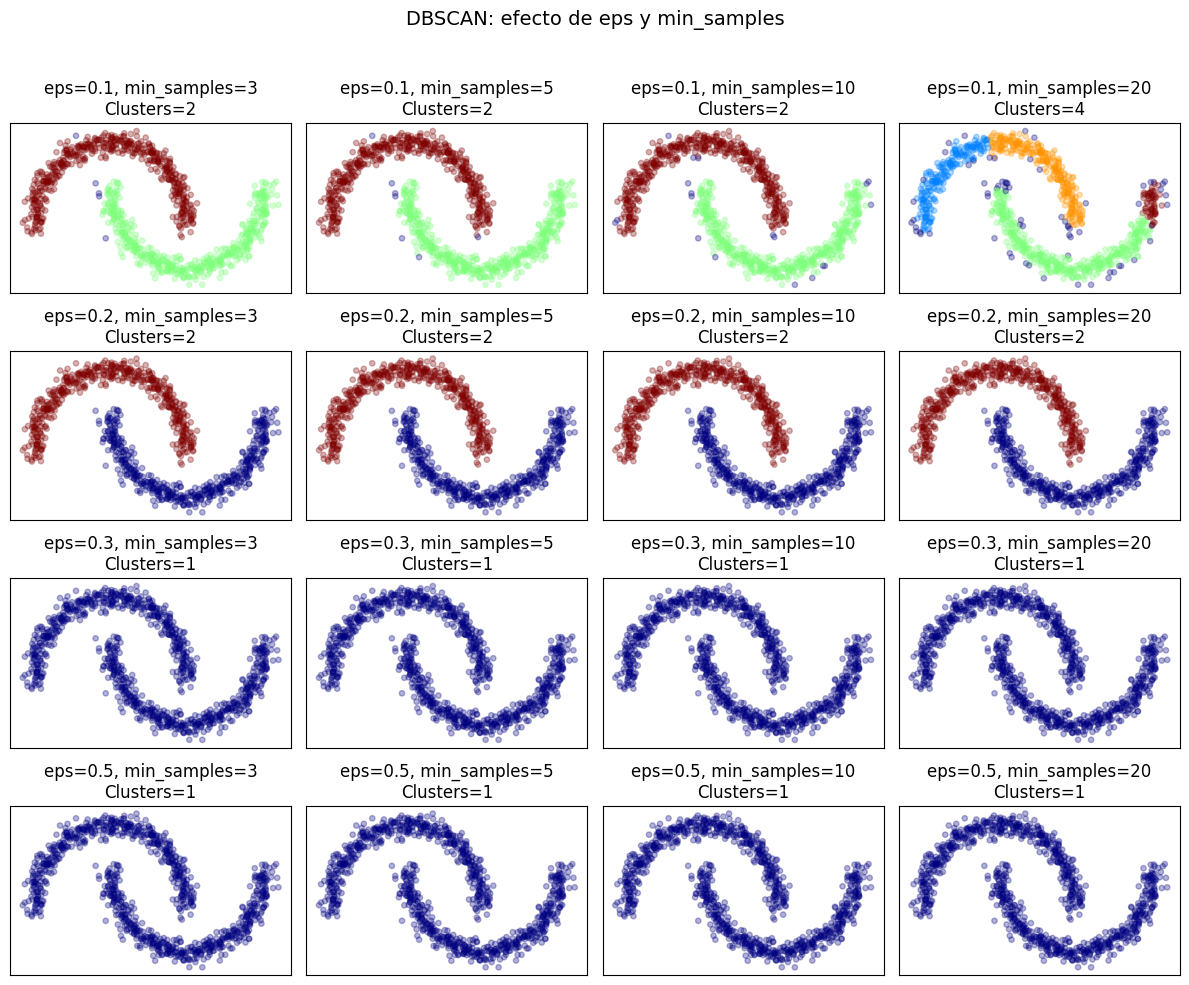

In [20]:
eps_values = [0.1, 0.2, 0.3, 0.5]
min_samples_values = [3, 5, 10, 20]

fig, axes = plt.subplots(len(eps_values), len(min_samples_values), figsize=(12, 10))
fig.suptitle("DBSCAN: efecto de eps y min_samples", fontsize=14)

for i, eps in enumerate(eps_values):
    for j, min_s in enumerate(min_samples_values):
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        axes[i, j].scatter(X[:, 0], X[:, 1], c=labels, cmap="jet", s=15, alpha=0.3)
        axes[i, j].set_title(f"eps={eps}, min_samples={min_s}\nClusters={n_clusters}")
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué ha sucedido? Explica los motivos por los que crees que se ha producido ese resultado.  
</div>

In [21]:
X, y = X_circles, y_circles

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Prueba la implementación de DBSCAN jugando con los parámetros <i>eps</i> y <i>min_samples</i> para encontrar los grupos (y <i>outliers</i>) del dataset Circles.
</div>

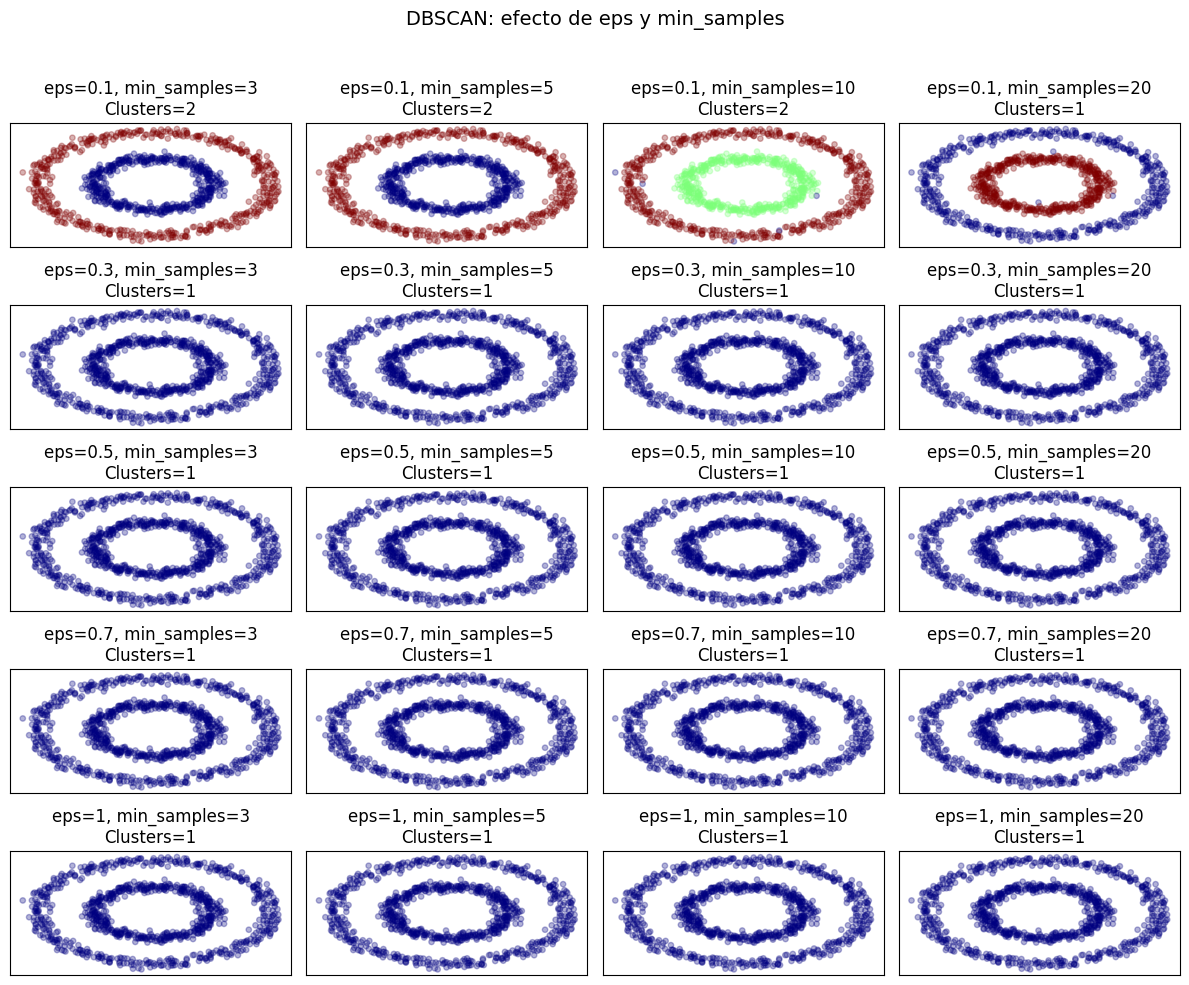

In [22]:
eps_values = [0.1, 0.3, 0.5, 0.7, 1]
min_samples_values = [3, 5, 10, 20]

fig, axes = plt.subplots(len(eps_values), len(min_samples_values), figsize=(12, 10))
fig.suptitle("DBSCAN: efecto de eps y min_samples", fontsize=14)

for i, eps in enumerate(eps_values):
    for j, min_s in enumerate(min_samples_values):
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        axes[i, j].scatter(X[:, 0], X[:, 1], c=labels, cmap="jet", s=15, alpha=0.3)
        axes[i, j].set_title(f"eps={eps}, min_samples={min_s}\nClusters={n_clusters}")
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué ha sucedido? Explica los motivos por los que crees que se ha producido ese resultado.  
</div>

### 1 c. Algoritmos jerárquicos

En este apartado se pide visualizar mediante un [dendrograma](https://en.wikipedia.org/wiki/Dendrogram) la construcción progresiva de los grupos mediante un algoritmo jerárquico aglomerativo (estrategia *bottom-up*). Con ello se pretende encontrar un método gráfico para entender el comportamiento del algoritmo y encontrar los *clusters* deseados en cada dataset.

In [23]:
X, y = X_blobs, y_blobs

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Prueba la implementación de <a href="https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html">clustering jerárquico de scipy</a> probando distintos <a href="https://en.wikipedia.org/wiki/Hierarchical_clustering#Linkage_criteria">criterios de enlace o <i>linkage</i></a> permitiendo identificar los clusters subyacentes (mostrando su resultado) y su dendrograma para el dataset Blobs.<br>
Puedes importar las librerías necesarias para ello.
</div>

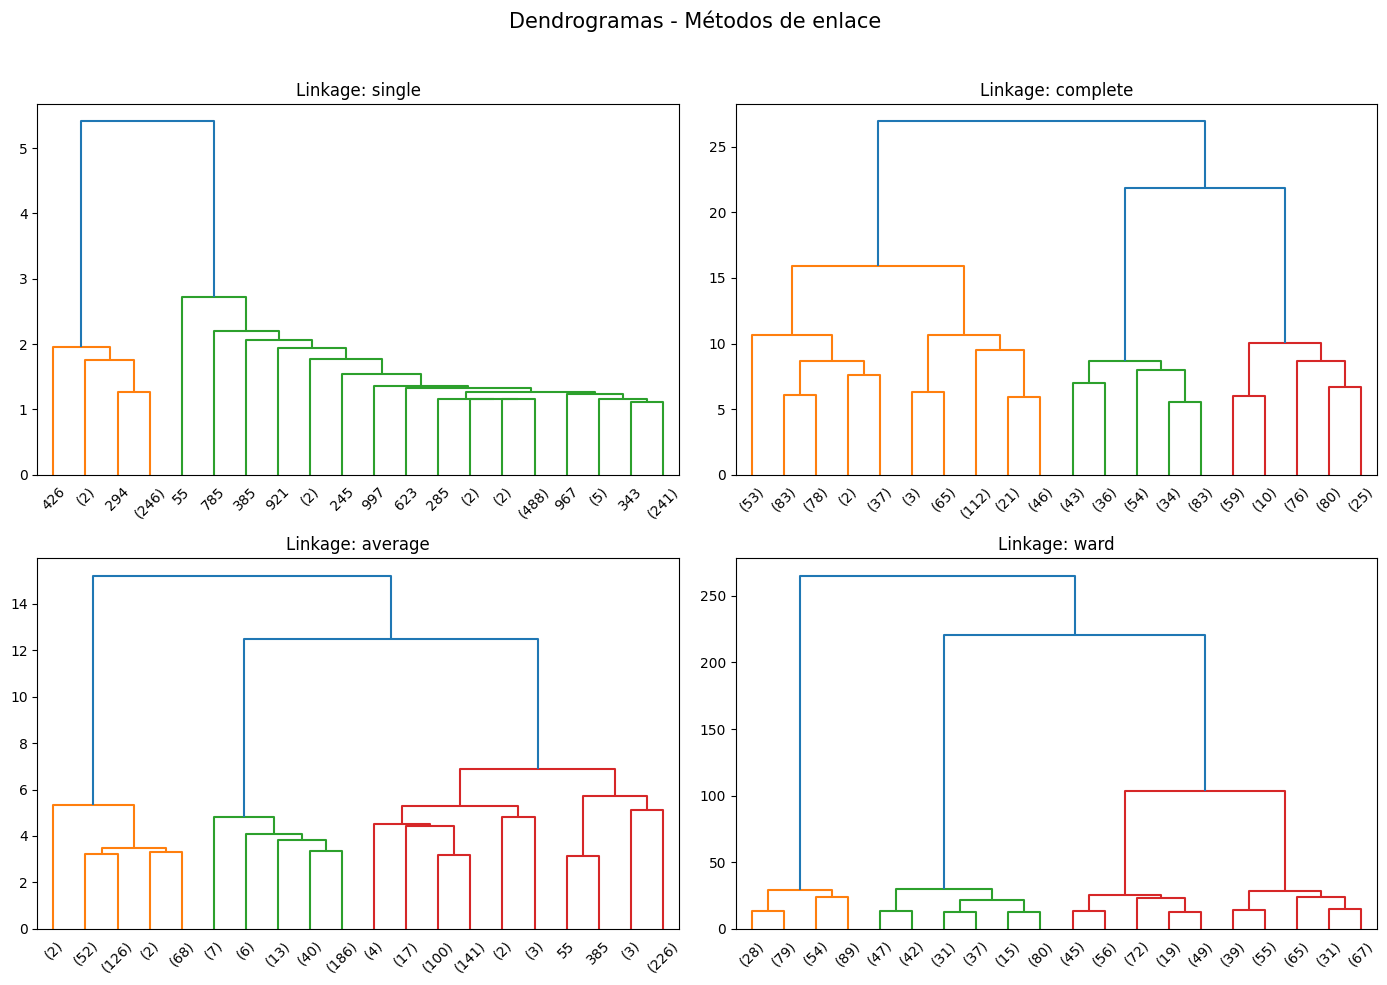

In [24]:
linkage_methods = ["single", "complete", "average", "ward"]

plt.figure(figsize=(14, 10))
plt.suptitle("Dendrogramas - Métodos de enlace", fontsize=15)

for i, method in enumerate(linkage_methods, 1):
    plt.subplot(2, 2, i)
    Z = linkage(X, method=method)
    dendrogram(Z, truncate_mode="lastp", p=20, leaf_rotation=45., leaf_font_size=10.)
    plt.title(f"Linkage: {method}")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

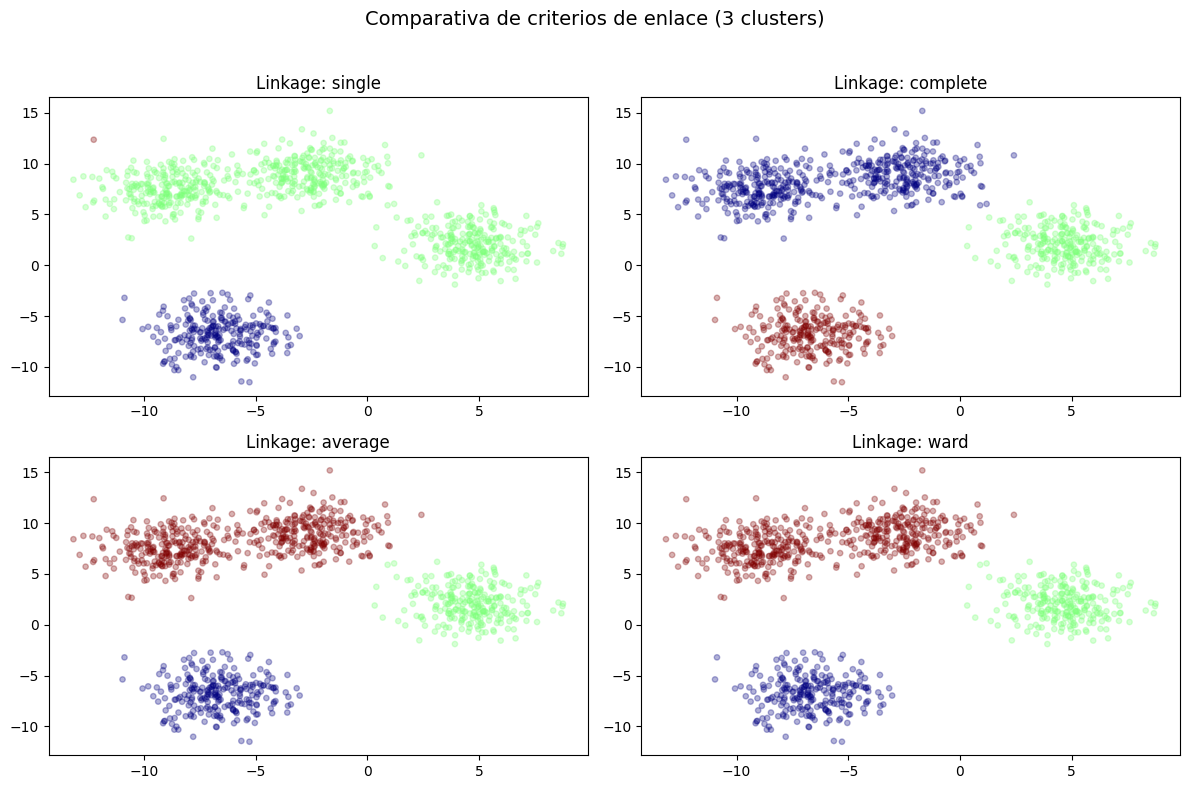

In [25]:
plt.figure(figsize=(12, 8))
for i, method in enumerate(linkage_methods, 1):
    Z = linkage(X, method=method)
    clusters = fcluster(Z, 3, criterion="maxclust")
    plt.subplot(2, 2, i)
    plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap="jet", s=15, alpha=0.3)
    plt.title(f"Linkage: {method}")
plt.suptitle("Comparativa de criterios de enlace (3 clusters)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Interpreta el dendrograma y comenta qué criterio de enlace se ha comportado mejor. ¿Por qué?
</div>

In [26]:
X, y = X_moons, y_moons

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Prueba la implementación de <a href="https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html">clustering jerárquico de scipy</a> probando distintos <a href="https://en.wikipedia.org/wiki/Hierarchical_clustering#Linkage_criteria">criterios de enlace o <i>linkage</i></a> permitiendo identificar los clusters subyacentes (mostrando su resultado) y su dendrograma para el dataset Moons.<br>
Puedes importar las librerías necesarias para ello.
</div>

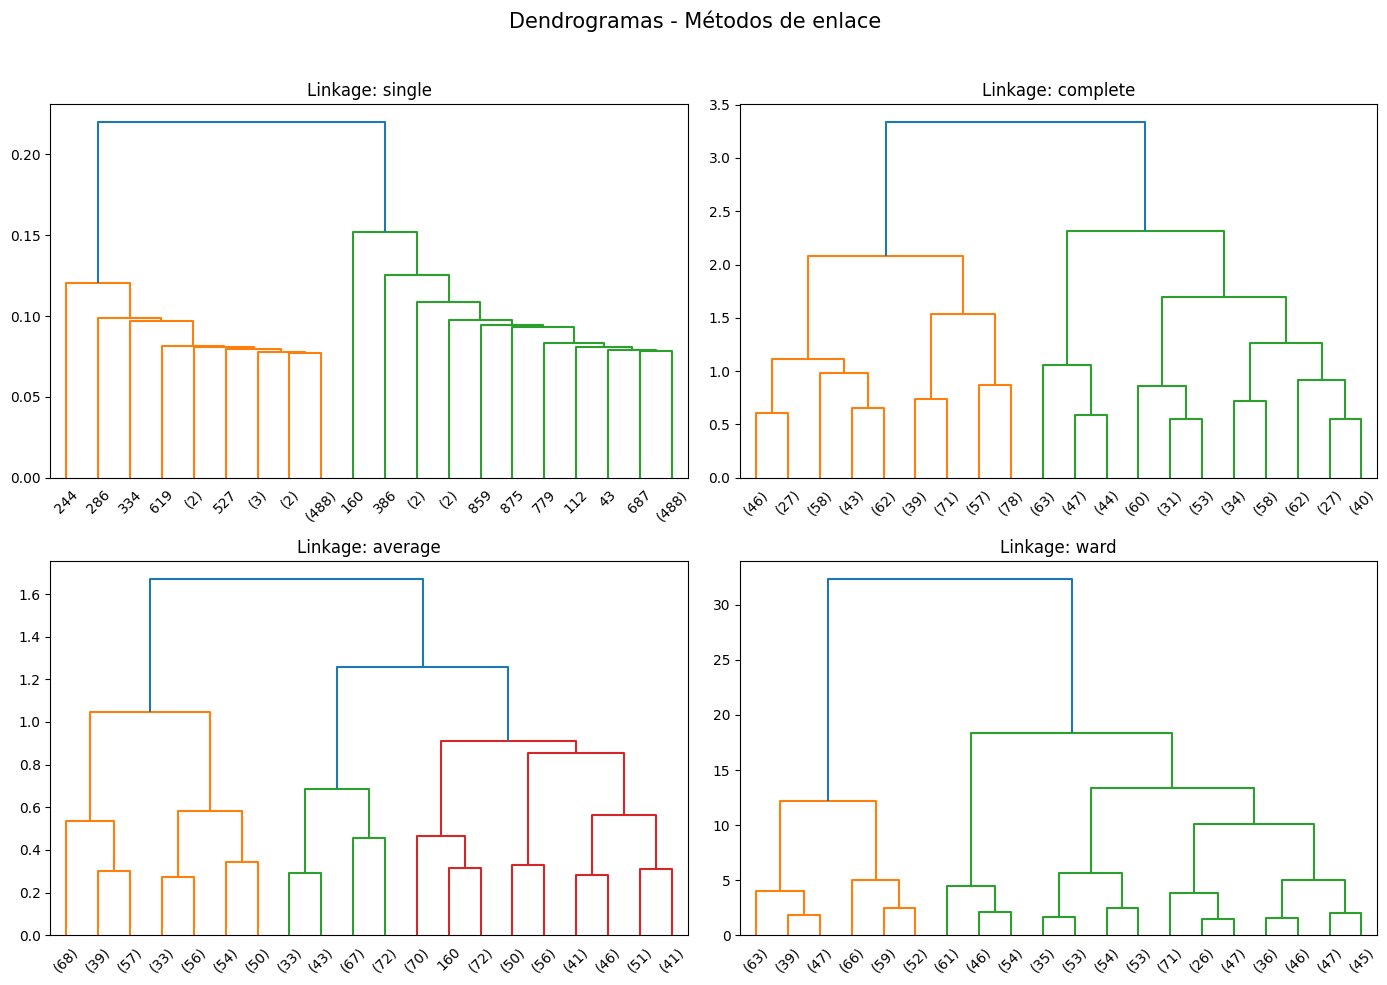

In [27]:
linkage_methods = ["single", "complete", "average", "ward"]

plt.figure(figsize=(14, 10))
plt.suptitle("Dendrogramas - Métodos de enlace", fontsize=15)

for i, method in enumerate(linkage_methods, 1):
    plt.subplot(2, 2, i)
    Z = linkage(X, method=method)
    dendrogram(Z, truncate_mode="lastp", p=20, leaf_rotation=45., leaf_font_size=10.)
    plt.title(f"Linkage: {method}")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

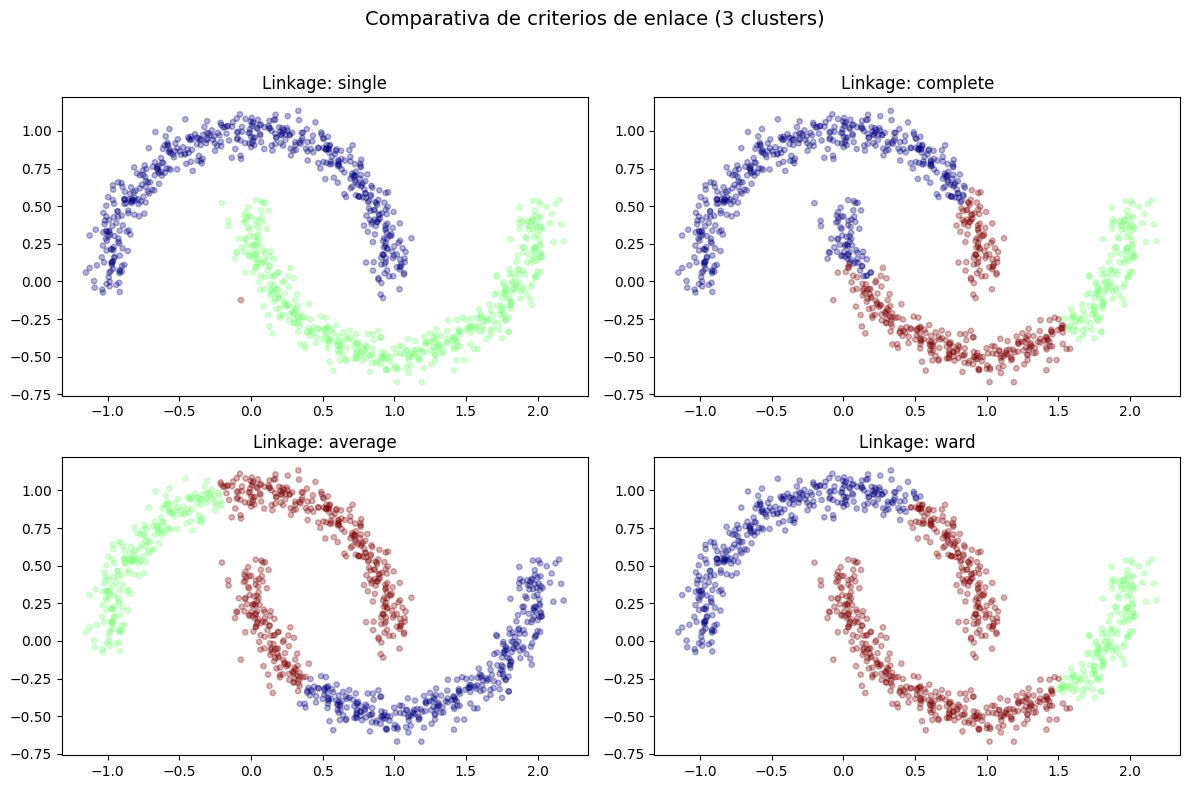

In [28]:
plt.figure(figsize=(12, 8))
for i, method in enumerate(linkage_methods, 1):
    Z = linkage(X, method=method)
    clusters = fcluster(Z, 3, criterion="maxclust")
    plt.subplot(2, 2, i)
    plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap="jet", s=15, alpha=0.3)
    plt.title(f"Linkage: {method}")
plt.suptitle("Comparativa de criterios de enlace (3 clusters)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Interpreta el dendrograma y comenta qué criterio de enlace se ha comportado mejor. ¿Por qué?
</div>

In [29]:
X, y = X_circles, y_circles

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Prueba la implementación de <a href="https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html">clustering jerárquico de scipy</a> probando distintos <a href="https://en.wikipedia.org/wiki/Hierarchical_clustering#Linkage_criteria">criterios de enlace o <i>linkage</i></a> permitiendo identificar los clusters subyacentes (mostrando su resultado) y su dendrograma para el dataset Circles.<br>
Puedes importar las librerías necesarias para ello.
</div>

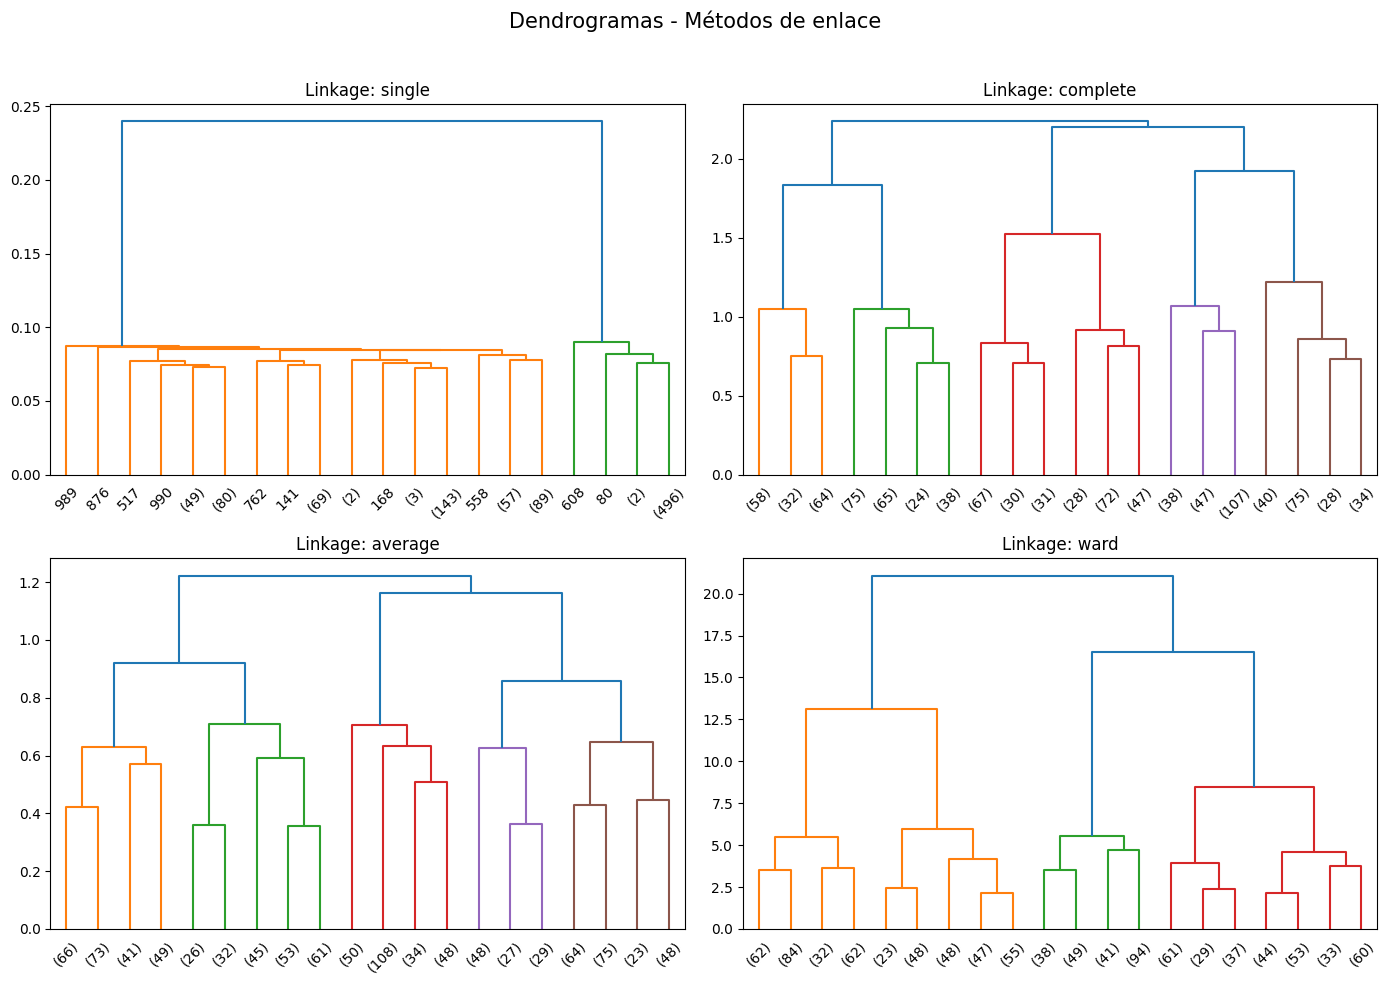

In [30]:
linkage_methods = ["single", "complete", "average", "ward"]

plt.figure(figsize=(14, 10))
plt.suptitle("Dendrogramas - Métodos de enlace", fontsize=15)

for i, method in enumerate(linkage_methods, 1):
    plt.subplot(2, 2, i)
    Z = linkage(X, method=method)
    dendrogram(Z, truncate_mode="lastp", p=20, leaf_rotation=45., leaf_font_size=10.)
    plt.title(f"Linkage: {method}")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

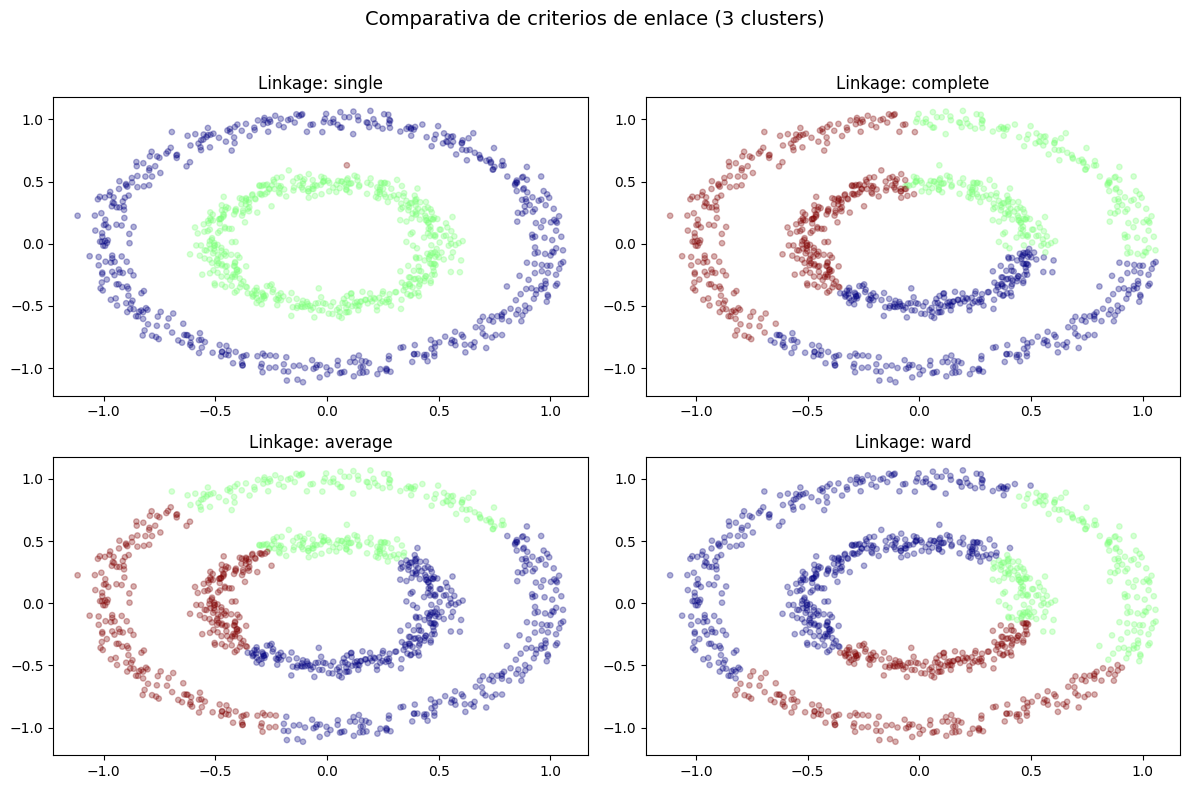

In [31]:
plt.figure(figsize=(12, 8))
for i, method in enumerate(linkage_methods, 1):
    Z = linkage(X, method=method)
    clusters = fcluster(Z, 3, criterion="maxclust")
    plt.subplot(2, 2, i)
    plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap="jet", s=15, alpha=0.3)
    plt.title(f"Linkage: {method}")
plt.suptitle("Comparativa de criterios de enlace (3 clusters)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Interpreta el dendrograma y comenta qué criterio de enlace se ha comportado mejor. ¿Por qué?
</div>

## 2. *Clustering* y reducción de dimensionalidad culinaria: (6 puntos)

En este ejercicio exploraremos cómo mediante clustering podemos descubrir patrones ocultos en miles de recetas reales de Food.com. Partiremos de un conjunto de unas 30.000 recetas con su nombre, descripción e ingredientes, y nuestro objetivo será agruparlas por similitud para ver qué tipos de platos emergen sin supervisión: ¿se juntan los postres? ¿los platos con ajo? ¿las recetas mediterráneas?

Probaremos distintas formas de representar las recetas: desde una codificación one-hot basada en los ingredientes, hasta embeddings semánticos generados con modelos de lenguaje (como MiniLM). Con ello veremos cómo cambia la estructura de los datos según el tipo de representación y qué tipo de similitud capturan mejor.

Finalmente aplicaremos técnicas de reducción de dimensionalidad con UMAP y varios métodos de clustering que podrás probar (KMeans, DBSCAN, HDBSCAN, Mean-shift, jerárquico...) para visualizar y analizar los grupos resultantes. Terminaremos interpretando los clusters más grandes a través de sus ingredientes y recetas representativas, comparando qué enfoque refleja mejor la *lógica culinaria* del conjunto.

In [32]:
df_original = pd.read_csv('./data/recipes.csv')
df_original.head(3)

,id,name,description,ingredients,ingredients_raw_str,serving_size,servings,steps,tags,search_terms
0,56594,Sun-Dried Tomato Palmiers,"from ""INVITATION TO DINNER"" cookbook","['garlic cloves', 'pesto sauce', 'frozen puff ...","[""2 garlic cloves, peeled and finely min...",1 (675 g),1,"['Preheat the oven to 350 degrees F.', 'Stir t...","['60-minutes-or-less', 'time-to-make', 'course...",{'appetizer'}
1,311362,Char Siu Pork Corn and Bok Choy Stir Fry,Here is another wok recipe I like stir fry's a...,"['peanut oil', 'pork fillets', 'garlic cloves'...","[""2 tablespoons peanut oil"",""600 g p...",1 (364 g),4,['Heat 1 tabelspoon of oil in a wok and cook p...,"['60-minutes-or-less', 'time-to-make', 'course...","{'pork', 'dinner'}"
2,248335,Black Cat Fudge,These adorable fudge peices will be a huge hit...,"['semisweet chocolate', 'butter', 'light corn ...","[""8 ounces semisweet chocolate, coarsely ...",1 (42 g),24,"['Line 11x7 inches pan with foil, extending fo...","['time-to-make', 'course', 'preparation', 'occ...",{'dessert'}


In [33]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   50000 non-null  int64 
 1   name                 50000 non-null  object
 2   description          49053 non-null  object
 3   ingredients          50000 non-null  object
 4   ingredients_raw_str  50000 non-null  object
 5   serving_size         50000 non-null  object
 6   servings             50000 non-null  int64 
 7   steps                50000 non-null  object
 8   tags                 50000 non-null  object
 9   search_terms         50000 non-null  object
dtypes: int64(2), object(8)
memory usage: 3.8+ MB


In [34]:
df_sample = df_original.sample(30000).reset_index(drop= True)
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   30000 non-null  int64 
 1   name                 30000 non-null  object
 2   description          29422 non-null  object
 3   ingredients          30000 non-null  object
 4   ingredients_raw_str  30000 non-null  object
 5   serving_size         30000 non-null  object
 6   servings             30000 non-null  int64 
 7   steps                30000 non-null  object
 8   tags                 30000 non-null  object
 9   search_terms         30000 non-null  object
dtypes: int64(2), object(8)
memory usage: 2.3+ MB


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Crea una nueva columna en el <em>DataFrame</em> que contenga, en una sola cadena de texto,
    <strong>toda la información disponible de cada receta</strong>. Concatena, en ese orden:
  <ul>
    <li>Título (<code>name</code>)</li>
    <li>Descripción (<code>description</code>)</li>
    <li>Lista de ingredientes (<code>ingredients</code>)</li>
    <li>Pasos de preparación (<code>steps</code>)</li>
    <li>Etiquetas (<code>tags</code>) y, si existe, términos de búsqueda (<code>search_terms</code>)</li>
  </ul>
  <p>
    Esta columna representará una descripción textual completa de la receta y se usará en el siguiente paso
    para generar sus <strong>embeddings semánticos</strong>.
  </p>
  <p>
    Ten en cuenta:
  </p>
  <ul>
    <li>Convierte listas o conjuntos a texto legible (por ejemplo, separando por comas).</li>
    <li>Gestiona valores nulos para evitar errores de concatenación.</li>
    <li>Verifica que el texto resultante mantiene la información relevante y es coherente.</li>
  </ul>
</div>

In [35]:
# Limpiar nulos
df_sample = df_sample.fillna("")

# Limpiar y formatear listas, carácteres innecesarios y espacios múltiples
for c in ["ingredients", "steps", "tags", "search_terms"]:
    df_sample[c] = (
        df_sample[c]
        # Sustituye guiones y puntos por espacio
        .str.replace("-", " ", regex= False)
        .str.replace(".", " ", regex=False)
        # Quita corchetes, llaves y comillas
        .str.replace(r"[\[\]\{\}']", "", regex=True)
        # Eliminar comas
        .str.replace(",", " ")

        # Espacios dobles
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

df_sample.head(3)

,id,name,description,ingredients,ingredients_raw_str,serving_size,servings,steps,tags,search_terms
0,306116,Grape Melon Medley,Found this in an old TOH. Haven't tried it yet...,cantaloupe green grapes red seedless grapes ma...,"[""2 cups cubed cantaloupe"",""1 1/2 cups ...",1 (155 g),8,In a large combine the cantaloupe grapes and o...,15 minutes or less time to make course main in...,healthy low calorie low fat low sodium
1,530235,Tasty Homemade Hamburger,I wanted a tasty juicy homemade burger. I add ...,onion powder garlic powder onion worcestershir...,"[""1 tablespoon onion powder"",""1 tablesp...",1 (135 g),8,Put ground bee f into a large bowl Add two egg...,60 minutes or less time to make course prepara...,lunch
2,197232,Aunt T's Amazing Pumpkin Bread,This recipe has been in our family for as long...,eggs water vegetable oil pumpkin flour sugar b...,"[""4 eggs"",""2/3 cup water"",""1 cup ...",1 (134 g),16,Preheat oven to 350°F and grease two loaf pans...,time to make course preparation occasion for l...,bread


In [36]:
# Concatenar columnas [name, description, ingredients, steps, tags y search_terms] con "." como separador
df_sample["full_text"] = (
    df_sample["name"].str.strip() + ". " +
    df_sample["description"].str.strip() + ". " +
    df_sample["ingredients"].str.strip() + ". " +
    df_sample["steps"].str.strip() + ". " +
    df_sample["tags"].str.strip() + ". " +
    df_sample["search_terms"].str.strip()
)


print(df_sample["full_text"].iloc[0])

Grape Melon Medley. Found this in an old TOH. Haven't tried it yet but since my oldest son LOVES fruit I thought I'd put it here for safe keeping.. cantaloupe green grapes red seedless grapes mandarin oranges pineapple preserves. In a large combine the cantaloupe grapes and oranges Whisk the preserves and pour over fruit; toss to coat Chill until serving. 15 minutes or less time to make course main ingredient preparation low protein healthy 5 ingredients or less salads fruit easy beginner cook kid friendly low fat dietary low sodium low cholesterol low saturated fat low calorie healthy 2 low in something citrus oranges melons 3 steps or less. healthy low calorie low fat low sodium


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Genera los <strong>embeddings semánticos</strong> de las recetas utilizando el modelo 
    <code>all-MiniLM-L6-v2</code> de la librería <code>sentence-transformers</code>.
    Este modelo es una versión ligera de BERT que transforma frases completas en vectores numéricos
    que capturan su significado.
  <p>
    Usa como entrada la columna con toda la información de la receta (título, descripción, ingredientes, pasos y etiquetas)
    para obtener una representación semántica de cada una.
  </p>
  <p>
    Incrementa el parámetro <code>batch_size</code> en <code>encode()</code> para aprovechar mejor los recursos 
    y activa <code>show_progress_bar=True</code> para visualizar el progreso durante la generación de embeddings.
  </p>
</div>

In [37]:
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(df_sample["full_text"].tolist(), batch_size= 512, normalize_embeddings= True, show_progress_bar=True)

Batches:   0%|          | 0/59 [00:00<?, ?it/s]

In [38]:
print(embeddings[0:5])

[[-0.02024057  0.02375573 -0.00130623 ...  0.02400626  0.0399929
   0.02369322]
 [-0.09952713 -0.04383076  0.00892251 ...  0.05787218 -0.04125084
  -0.01198423]
 [-0.01508697  0.03139937  0.02370081 ... -0.05417378 -0.031132
  -0.05552405]
 [-0.01826955  0.02959367 -0.03273237 ...  0.00544147  0.03540883
  -0.0267105 ]
 [ 0.02472819 -0.02905949  0.06766732 ...  0.0083181  -0.03393503
  -0.13612278]]


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Reduce los <strong>embeddings</strong> obtenidos a un espacio de <strong>2 dimensiones</strong> utilizando 
    <code>UMAP</code> (<em>Uniform Manifold Approximation and Projection</em>), una técnica de reducción de dimensionalidad
    que conserva la estructura local de los datos en espacios de alta dimensión.
  <p>
    UMAP busca representar los datos en un espacio más pequeño manteniendo la relación entre puntos similares,
    lo que lo hace ideal para visualizar embeddings en 2D y detectar grupos o patrones de manera intuitiva.
    En comparación con <em>t-SNE</em>, UMAP es más rápido, escalable, permite la proyección de nuevos puntos y preserva mejor la estructura global de los datos.
    Puedes consultar una comparación visual detallada en 
    <a href="https://pair-code.github.io/understanding-umap/" target="_blank">esta página</a>.
  </p>
  <p>
    Aplica UMAP sobre la matriz de embeddings y guarda el resultado en una nueva variable que contenga las coordenadas 2D
    de cada receta para su posterior visualización o análisis.
  </p>
</div>

In [55]:
reduction = umap.UMAP(n_components= 2, n_neighbors= 100, min_dist= 0.05, random_state= 42, metric= "cosine")
embeddings_2d = reduction.fit_transform(embeddings)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Visualiza el resultado de la reducción a 2D con <code>UMAP</code> mediante un <strong>scatter plot</strong>.
    Representa cada receta como un punto en el plano y observa si se forman grupos o regiones con mayor densidad.
  <p>
    Para mejorar la legibilidad del gráfico:
  </p>
  <ul>
    <li>
      Ajusta el parámetro <code>alpha</code> para controlar la <strong>transparencia</strong> de los puntos:
      valores más bajos (por ejemplo, 0.3) permiten visualizar mejor las zonas donde los puntos se solapan,
      haciendo más visibles las regiones densas.
    </li>
    <li>
      Reduce el parámetro <code>s</code> (tamaño de los puntos) para evitar que se superpongan en exceso
      y poder distinguir mejor la estructura general del conjunto.
    </li>
  </ul>
</div>

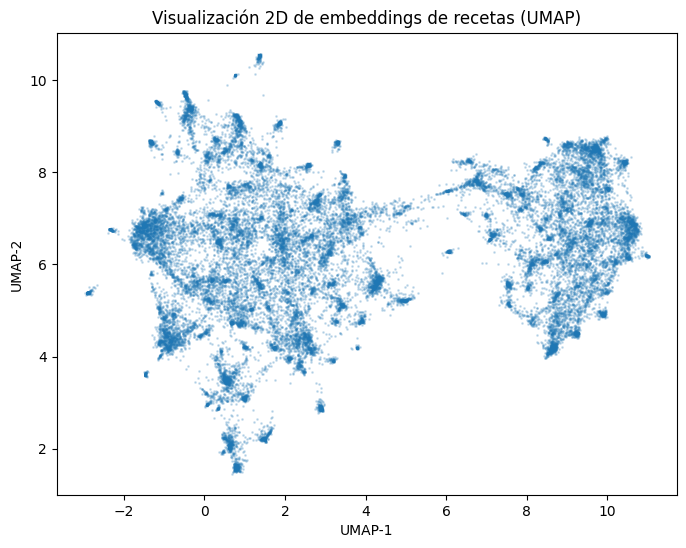

In [56]:
df_umap = pd.DataFrame()
df_umap["x_umap"] = embeddings_2d[:, 0]
df_umap["y_umap"] = embeddings_2d[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(df_umap["x_umap"], df_umap["y_umap"], s=1, alpha=0.2)
plt.title("Visualización 2D de embeddings de recetas (UMAP)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> <strong>sobre qué datos realizar el clustering</strong>: 
    ¿sobre los datos reducidos en 2D o sobre los embeddings originales en alta dimensionalidad?
  <p>
    Justifica tu elección explicando las posibles consecuencias de aplicar el algoritmo 
    de clustering sobre una representación reducida en comparación con la original.
  </p>
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Visualiza las recetas en su <strong>espacio original de alta dimensionalidad</strong> utilizando 
    un <strong>dendrograma</strong>. 
    Esto te permitirá analizar la estructura de los datos y comparar si las agrupaciones observadas 
    coinciden con las que aparecían en la proyección 2D de <code>UMAP</code>.
  <p>
    Comenta qué puedes inferir al observar el dendrograma:
    si existen grupos bien definidos o si las fusiones son graduales,
    y cómo se relaciona esa estructura jerárquica con las regiones que aparecían en la visualización reducida.
  </p>
</div>

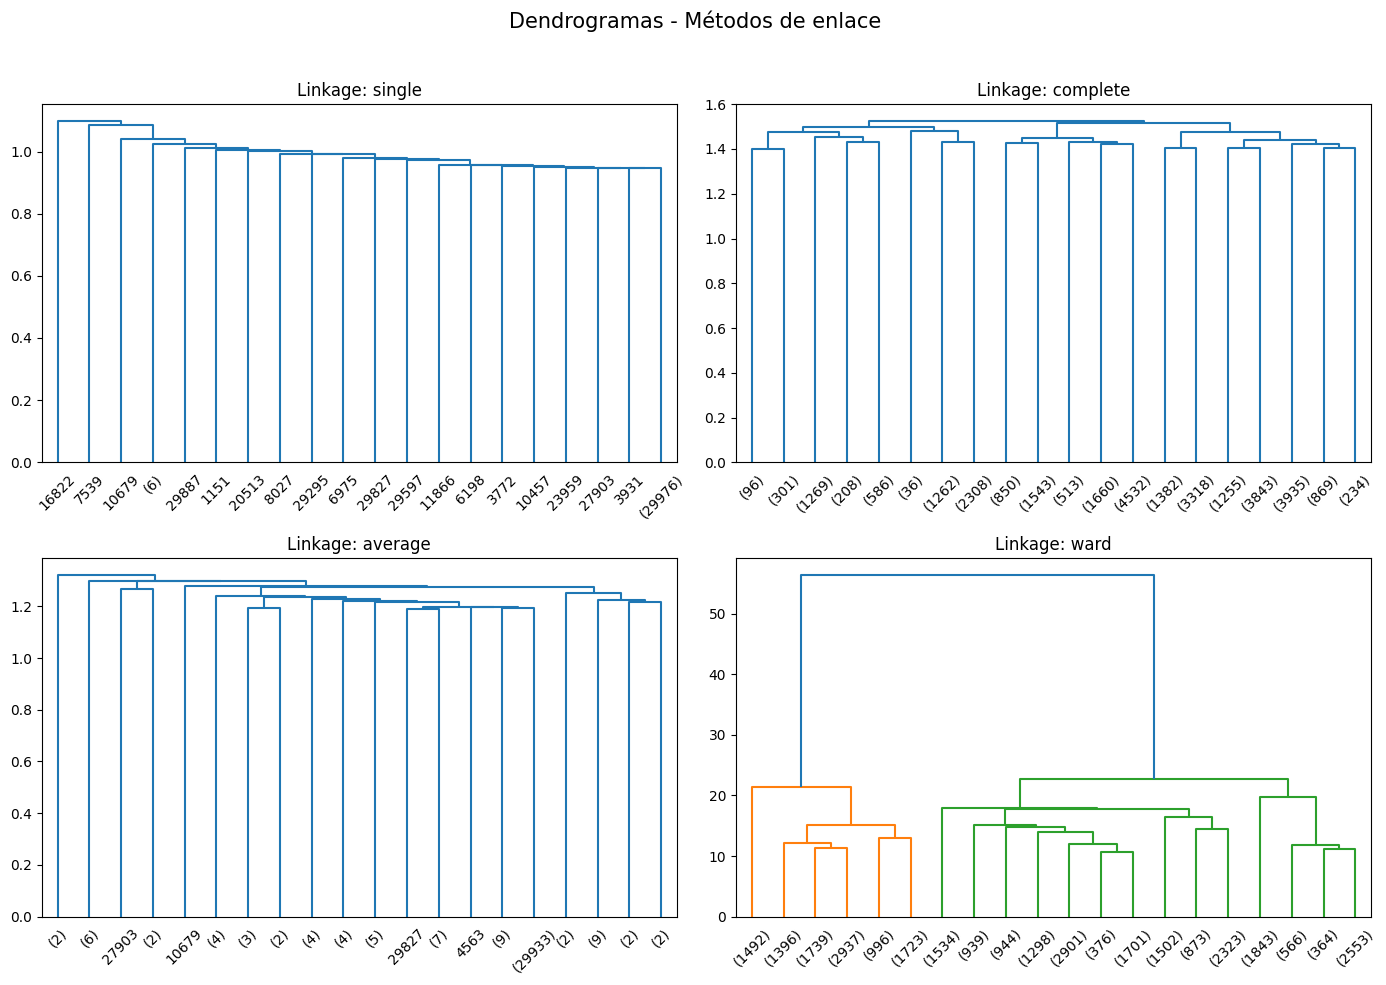

In [41]:
linkage_methods = ["single", "complete", "average", "ward"]

plt.figure(figsize=(14, 10))
plt.suptitle("Dendrogramas - Métodos de enlace", fontsize=15)

for i, method in enumerate(linkage_methods, 1):
    plt.subplot(2, 2, i)
    Z = linkage(embeddings, method=method)
    dendrogram(Z, truncate_mode="lastp", p=20, leaf_rotation=45., leaf_font_size=10.)
    plt.title(f"Linkage: {method}")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Dado lo observado en la reducción de dimensionalidad con <code>UMAP</code> y en el dendrograma obtenido,
    decide <strong>qué algoritmo de clustering</strong> utilizarías para identificar los grupos de recetas.
    Explica con qué argumentos lo elegirías y justifica tu respuesta en función de la estructura observada 
    en los datos (densidad, tamaño y forma de los grupos).
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Implementa el algoritmo elegido y analiza sus posibles parámetros para obtener el resultado deseado.
</div>

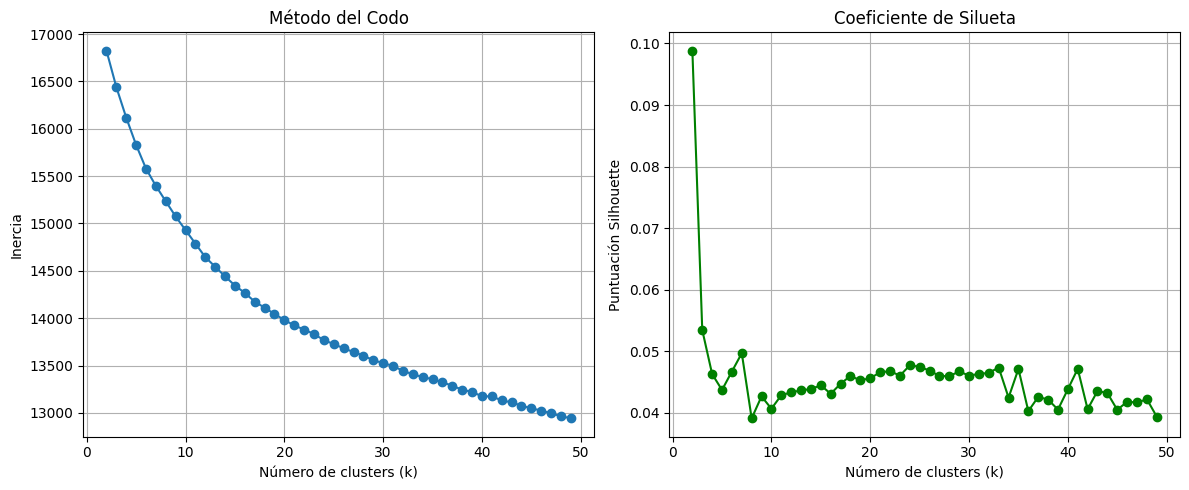

k=2: Inercia=16824.39, Silhouette=0.0988
k=3: Inercia=16438.78, Silhouette=0.0535
k=4: Inercia=16117.15, Silhouette=0.0463
k=5: Inercia=15828.90, Silhouette=0.0437
k=6: Inercia=15579.06, Silhouette=0.0467
k=7: Inercia=15396.40, Silhouette=0.0497
k=8: Inercia=15234.31, Silhouette=0.0391
k=9: Inercia=15073.94, Silhouette=0.0427
k=10: Inercia=14930.40, Silhouette=0.0407
k=11: Inercia=14787.36, Silhouette=0.0429
k=12: Inercia=14644.57, Silhouette=0.0434
k=13: Inercia=14543.30, Silhouette=0.0437
k=14: Inercia=14441.51, Silhouette=0.0439
k=15: Inercia=14345.01, Silhouette=0.0445
k=16: Inercia=14266.97, Silhouette=0.0431
k=17: Inercia=14174.97, Silhouette=0.0447
k=18: Inercia=14110.99, Silhouette=0.0460
k=19: Inercia=14044.48, Silhouette=0.0453
k=20: Inercia=13981.59, Silhouette=0.0456
k=21: Inercia=13923.51, Silhouette=0.0466
k=22: Inercia=13880.30, Silhouette=0.0468
k=23: Inercia=13832.62, Silhouette=0.0461
k=24: Inercia=13768.55, Silhouette=0.0477
k=25: Inercia=13726.61, Silhouette=0.0475


In [57]:
# Rango de posibles k
k_values = range(2, 50)

inertias = []       # Para el método del codo
silhouettes = []    # Para el coeficiente de silueta

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_kmeans = kmeans.fit_predict(embeddings)
    
    # Inercia (suma de distancias cuadradas dentro de los clusters)
    inertias.append(kmeans.inertia_)
    
    # Silhouette (medida de cohesión y separación)
    silhouette_avg = silhouette_score(embeddings, labels_kmeans)
    silhouettes.append(silhouette_avg)

# --- Visualizar el método del codo ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_values, inertias, marker="o")
plt.title("Método del Codo")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.grid(True)

# --- Visualizar el coeficiente de silueta ---
plt.subplot(1, 2, 2)
plt.plot(k_values, silhouettes, marker="o", color="green")
plt.title("Coeficiente de Silueta")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Puntuación Silhouette")
plt.grid(True)

plt.tight_layout()
plt.show()

# Mostrar resultados numéricos
for k, inertia, sil in zip(k_values, inertias, silhouettes):
    print(f"k={k}: Inercia={inertia:.2f}, Silhouette={sil:.4f}")

# Sugerir el mejor k (máximo de silueta)
sorted_indices = np.argsort(silhouettes)[::-1]
best_k = k_values[sorted_indices[0]]
best_k_2 = k_values[sorted_indices[1]]

print(f"🥇 Mejor k (silhouette más alto): {best_k}")
print(f"🥈 Segundo mejor k: {best_k_2}")

print(f"\n👉 El número óptimo de clusters según el coeficiente de silueta es: {best_k}")

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Representa en un <strong>scatter plot</strong> la proyección 2D (UMAP) coloreando cada punto según su
    <code>cluster</code>. Usa una paleta cualitativa rica en colores (como <code>tab20</code>). Si hay más clusters que colores disponibles, reutiliza colores
    aplicando el índice del cluster <em>módulo</em> el número de colores de la paleta.
</div>

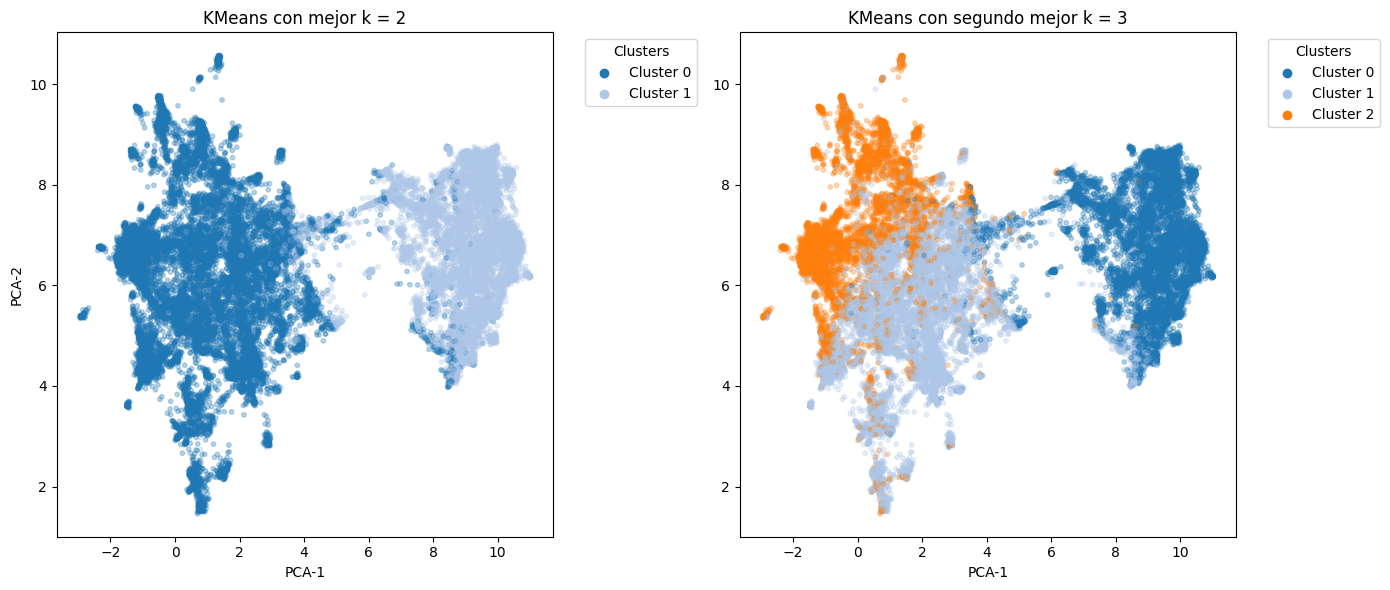

In [58]:
import seaborn as sns

# --- Entrenar KMeans con el mejor k ---
kmeans_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_best = kmeans_best.fit_predict(embeddings)

# --- Entrenar KMeans con el segundo mejor k ---
kmeans_second = KMeans(n_clusters=best_k_2, random_state=42, n_init=10)
labels_second = kmeans_second.fit_predict(embeddings)

# --- Paletas de colores ---
palette_best = sns.color_palette("tab20", n_colors=best_k)
palette_second = sns.color_palette("tab20", n_colors=best_k_2)

colors_best = [
    palette_best[label % len(palette_best)] if label >= 0 else (0.6, 0.6, 0.6)
    for label in labels_best
]

colors_second = [
    palette_second[label % len(palette_second)] if label >= 0 else (0.6, 0.6, 0.6)
    for label in labels_second
]

# --- Visualización lado a lado ---
plt.figure(figsize=(14, 6))

# Gráfico 1: mejor k
plt.subplot(1, 2, 1)
plt.scatter(
    embeddings_2d[:, 0], embeddings_2d[:, 1],
    c=colors_best, s=10, alpha=0.3
)
plt.title(f"KMeans con mejor k = {best_k}", fontsize=12)
plt.xlabel("UMAP-1" if "UMAP" in locals() else "PCA-1")
plt.ylabel("UMAP-2" if "UMAP" in locals() else "PCA-2")
unique_labels = np.unique(labels_best)
for label in unique_labels:
    plt.scatter([], [], color=palette_best[label % len(palette_best)], label=f"Cluster {label}")
plt.legend(title="Clusters", bbox_to_anchor=(1.05, 1), loc="upper left")
# Gráfico 2: segundo mejor k
plt.subplot(1, 2, 2)
plt.scatter(
    embeddings_2d[:, 0], embeddings_2d[:, 1],
    c=colors_second, s=10, alpha=0.3
)
plt.title(f"KMeans con segundo mejor k = {best_k_2}", fontsize=12)
plt.xlabel("UMAP-1" if "UMAP" in locals() else "PCA-1")
plt.ylabel("")
# --- Leyenda --- 
unique_labels = np.unique(labels_second)
for label in unique_labels:
    plt.scatter([], [], color=palette_second[label % len(palette_second)], label=f"Cluster {label}")
plt.legend(title="Clusters", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


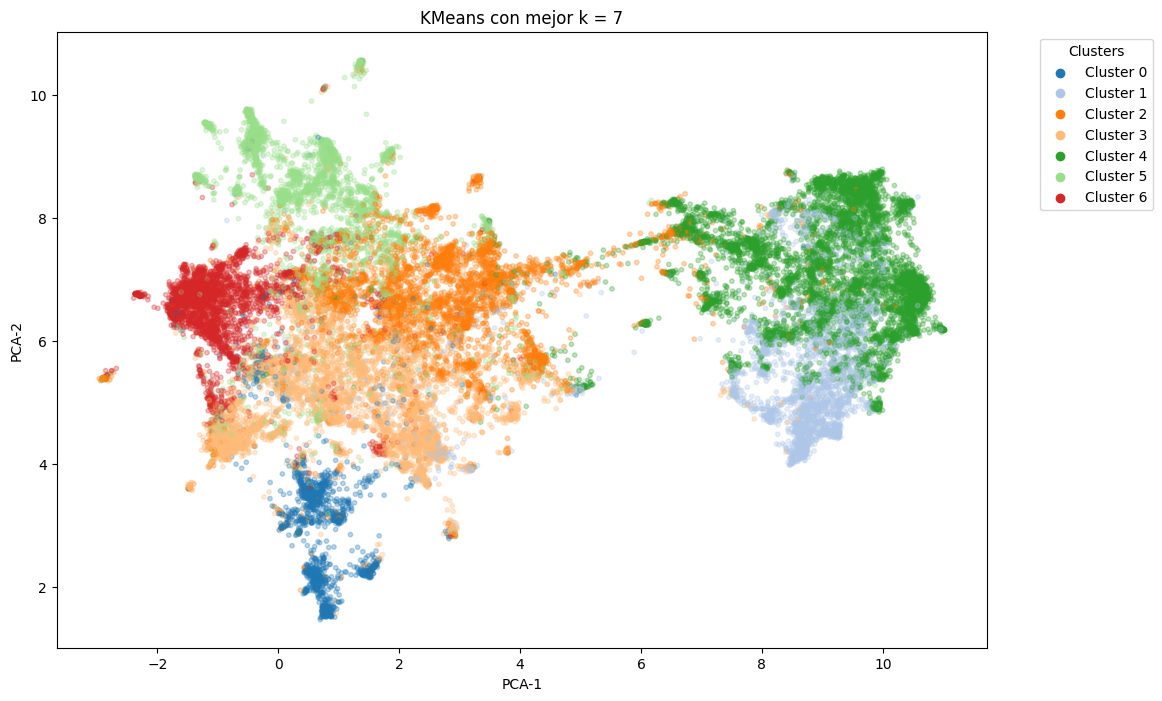

In [62]:
best_k_3 = 7
kmeans_3 = KMeans(n_clusters=best_k_3, random_state=42, n_init=10)
labels_third = kmeans_3.fit_predict(embeddings)
palette_third = sns.color_palette("tab20", n_colors=best_k_3)

colors_3 = [
    palette_third[label % len(palette_third)] if label >= 0 else (0.6, 0.6, 0.6)
    for label in labels_third
]

plt.figure(figsize=(12, 8))
plt.scatter(
    embeddings_2d[:, 0], embeddings_2d[:, 1],
    c=colors_3, s=10, alpha=0.3
)
plt.title(f"KMeans con mejor k = {best_k_3}", fontsize=12)
plt.xlabel("UMAP-1" if "UMAP" in locals() else "PCA-1")
plt.ylabel("UMAP-2" if "UMAP" in locals() else "PCA-2")
unique_labels = np.unique(labels_third)
for label in unique_labels:
    plt.scatter([], [], color=palette_third[label % len(palette_third)], label=f"Cluster {label}")
plt.legend(title="Clusters", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Para interpretar el clustering y validar su coherencia, selecciona los <strong>10 grupos</strong> con mayor tamaño y muestra,
    para cada uno, las <strong>5 recetas más cercanas al centroide</strong> (si el método lo define).
</div>

In [63]:
from sklearn.metrics.pairwise import cosine_distances

# Asegúrate de haber entrenado KMeans con k=8
k = 7
kmeans_final = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(embeddings)
df_sample["cluster"] = cluster_labels

# --- Seleccionar los 10 clusters más grandes (si hay menos, se mostrarán todos) ---
top_clusters = (
    df_sample["cluster"].value_counts()
    .head(10)
    .index
)
print(f"✅ Top {len(top_clusters)} clusters por tamaño:", list(top_clusters))

# --- Diccionario para guardar los resultados representativos ---
representantes = {}

# --- Calcular las 5 recetas más cercanas al centroide ---
for cluster_id in top_clusters:
    # Índices del cluster
    idx_cluster = df_sample[df_sample["cluster"] == cluster_id].index
    emb_cluster = embeddings[idx_cluster]

    # Centroide del cluster (definido por KMeans)
    centroide = kmeans_final.cluster_centers_[cluster_id].reshape(1, -1)

    # Calcular distancia coseno a cada receta dentro del cluster
    distancias = cosine_distances(centroide, emb_cluster)[0]

    # Seleccionar las 5 más cercanas
    top5_idx = idx_cluster[np.argsort(distancias)[:5]]

    representantes[cluster_id] = df_sample.loc[top5_idx, ["name", "description"]]

# --- Mostrar resultados ---
for cluster_id, recetas in representantes.items():
    print(f"\n🍳 Cluster {cluster_id} — {len(df_sample[df_sample['cluster'] == cluster_id])} recetas")
    print("-" * 70)
    for _, row in recetas.iterrows():
        nombre = row["name"][:70]
        desc = str(row["description"])[:150].replace("\n", " ")
        print(f"• {nombre}: {desc}...")


✅ Top 7 clusters por tamaño: [4, 3, 2, 5, 1, 6, 0]

🍳 Cluster 4 — 7099 recetas
----------------------------------------------------------------------
• Almond Buttercups: Looks very pretty on a holiday cookie tray.  I really enjoy these with a cup of hot tea....
• Confectioner's Sugar Cookies: ...
• Grab-And-Go Breakfast Cookies: I made these cookies from a home basics recipe with my own additions and omissions. Getting them ready to take camping and I sure hope they last that ...
• Sugar Cookies: Great for all kinds of holidays!...
• Milk Chocolate Pound Cake: Melted candy bars make this pound cake super moist....

🍳 Cluster 3 — 5821 recetas
----------------------------------------------------------------------
• Stir Fried Vegetables: Its a nice dish. There are three main ingredients, capsicum, onion and tomato....
• Red Pepper Coulis: Serve this sweet and spicy sauce on a simple burger or grilled fish or chicken and turn it into something special. We love it on vegetarian burgers an

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Observa los resultados del clustering e interpreta si los grupos obtenidos <strong>tienen sentido</strong> desde un punto de vista culinario. 
    Observa si las recetas dentro de un mismo cluster comparten ingredientes, estilo de preparación o tipo de plato 
    (por ejemplo, salsas, postres, carnes, ensaladas...). 
    Explica brevemente por qué crees que los clusters son o no coherentes.
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Vamos a crear una nueva representación de las recetas utilizando únicamente sus <strong>ingredientes</strong>. 
    Para ello, genera una matriz <em>one-hot</em> donde cada fila representa una receta y cada columna un ingrediente distinto.
    En esta matriz, el valor será <code>1</code> si la receta contiene ese ingrediente y <code>0</code> en caso contrario.
  <p>
    Puedes utilizar la clase <code>MultiLabelBinarizer</code> de <code>sklearn.preprocessing</code> 
    para transformar automáticamente las listas de ingredientes en vectores binarios.
  </p>
  <ul>
    <li>Usa la columna de ingredientes ya procesada (listas limpias y sin valores nulos).</li>
    <li>Guarda el resultado en una nueva variable o DataFrame y asegúrate de que el número de columnas coincide con el número total de ingredientes únicos.</li>
    <li>Esta representación servirá como nueva base para aplicar técnicas de reducción de dimensionalidad y clustering.</li>
  </ul>
</div>

In [64]:
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd

# --- Asegúrate de tener una columna con listas limpias de ingredientes ---
# Ejemplo: df["ingredients"] = [["tomate", "queso", "albahaca"], ["pollo", "ajo"], ...]
df_onehot = df_original.copy()
df_onehot = df_onehot.sample(30000).reset_index(drop=True)

df_onehot["ingredients"] = df_onehot["ingredients"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# --- Limpiar espacios y asegurar formato lista ---
df_onehot["ingredients"] = df_onehot["ingredients"].apply(
    lambda ingr_list: [i.strip() for i in ingr_list if isinstance(i, str)]
)

# --- Crear el binarizador ---
mlb = MultiLabelBinarizer()

# --- Ajustar y transformar ---
ingredientes_onehot = mlb.fit_transform(df_onehot["ingredients"])

# --- Crear DataFrame respetando los nombres originales ---
ingredientes_df = pd.DataFrame(
    ingredientes_onehot,
    columns=[str(ing) for ing in mlb.classes_],
    index=df_onehot.index
)

print(f"✅ Matriz one-hot creada con forma: {ingredientes_df.shape}")
print(f"Número total de ingredientes únicos: {len(mlb.classes_)}")

# Ver ejemplo de las primeras filas
ingredientes_df.head()


✅ Matriz one-hot creada con forma: (30000, 8683)
Número total de ingredientes únicos: 8683


,,%288.8-oz%29 pouch precooked basmati rice,1%25 fat buttermilk,1%25 fat cottage cheese,1%25 low-fat milk,10 bean soup mix,10%25 cream,10-inch baked pie shell,10-inch flour tortillas,10-inch whole wheat tortillas,...,zatarain%27s jambalaya mix,zatarain%27s%c2%ae spanish rice,zinfandel,ziploc bag,ziploc bags,ziti pasta,ziti rigati,zucchini,zucchini with italian-style tomato sauce,zwieback toast crumbs
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Aplica nuevamente <code>UMAP</code> para reducir la nueva representación <strong>one-hot de ingredientes</strong> 
    a un espacio de <strong>2 dimensiones</strong>. Esta reducción te permitirá visualizar las recetas en función de 
    la similitud de sus ingredientes y detectar posibles agrupaciones o patrones culinarios.
  <ul>
    <li>Usa los mismos parámetros de <code>UMAP</code> que antes para poder comparar visualmente ambas proyecciones.</li>
    <li>Guarda el resultado en una nueva variable con las coordenadas 2D de cada receta.</li>
  </ul>
</div>

In [65]:

# --- Asegúrate de tener la matriz one-hot ---
# ingredientes_df = DataFrame con 0/1 indicando presencia de ingredientes

# --- Definir el modelo UMAP (usando mismos parámetros que antes) ---

# --- Ajustar y transformar ---
ingredientes_2d = reduction.fit_transform(ingredientes_df)

# --- Guardar resultado en DataFrame ---
ingredientes_umap = pd.DataFrame(
    ingredientes_2d,
    columns=["UMAP_1", "UMAP_2"],
    index=ingredientes_df.index
)

print("✅ UMAP completado.")
print(f"Forma del espacio reducido: {ingredientes_df.shape}")

ingredientes_df.head()


✅ UMAP completado.
Forma del espacio reducido: (30000, 8683)


,,%288.8-oz%29 pouch precooked basmati rice,1%25 fat buttermilk,1%25 fat cottage cheese,1%25 low-fat milk,10 bean soup mix,10%25 cream,10-inch baked pie shell,10-inch flour tortillas,10-inch whole wheat tortillas,...,zatarain%27s jambalaya mix,zatarain%27s%c2%ae spanish rice,zinfandel,ziploc bag,ziploc bags,ziti pasta,ziti rigati,zucchini,zucchini with italian-style tomato sauce,zwieback toast crumbs
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Visualiza en un <strong>scatter plot</strong> la nueva proyección en 2D obtenida al aplicar 
    <code>UMAP</code> sobre la representación <strong>one-hot</strong> de los ingredientes. 
    Cada punto debe representar una receta, posicionada según la similitud de sus ingredientes.
</div>

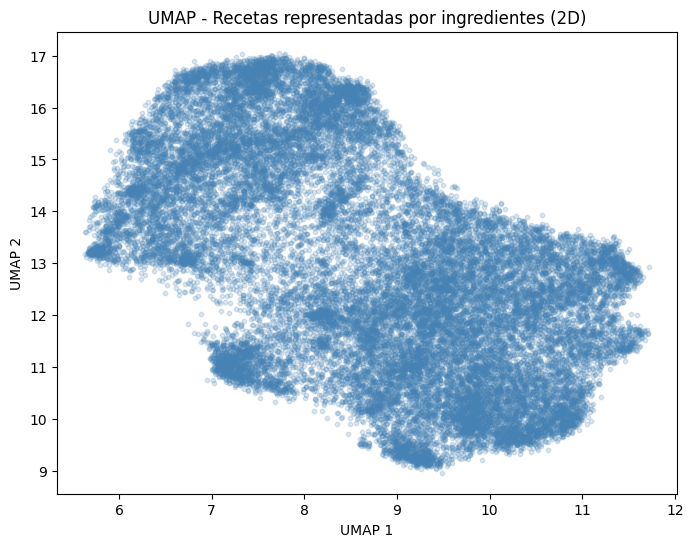

In [67]:
plt.figure(figsize=(8, 6))
plt.scatter(
    ingredientes_umap["UMAP_1"], ingredientes_umap["UMAP_2"],
    s=10, alpha=0.2, color="steelblue"
)
plt.title("UMAP - Recetas representadas por ingredientes (2D)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Compara la visualización obtenida con los <strong>embeddings semánticos</strong> (generados con MiniLM) 
    y la nueva proyección obtenida a partir de la <strong>representación one-hot</strong> de los ingredientes.
    Describe las principales diferencias que observes entre ambas.
  </p>
  <p>
    Justifica tu respuesta planteando una <strong>hipótesis</strong> sobre por qué los puntos se organizan de forma distinta 
    en cada caso. Puedes reflexionar sobre qué tipo de información captura cada representación y cómo eso afecta a la estructura 
    de los grupos observados.
  </p>
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> A partir de la nueva representación <strong>one-hot de ingredientes</strong>, decide qué 
    <strong>algoritmo de clustering</strong> utilizarías para agrupar las recetas. 
    Explica si mantendrías el mismo algoritmo usado en el caso anterior o si elegirías otro, 
    justificando tu decisión en función de la estructura observada en los datos.
  </p>
  <p>
    Si el algoritmo elegido requiere una <strong>métrica de similitud o distancia</strong>, 
    indica cuál utilizarías (por ejemplo, <em>Jaccard</em>, <em>coseno</em> o <em>euclídea</em>) 
    y argumenta por qué resulta más adecuada para este tipo de datos binarios.
  </p>
</div>

⏳ Probando valores de k entre 3 y 50...

k= 3 | Inercia=49723.93 | Silhouette=0.4299
k= 4 | Inercia=36439.52 | Silhouette=0.4391
k= 5 | Inercia=27176.93 | Silhouette=0.4169
k= 6 | Inercia=22431.34 | Silhouette=0.4141
k= 7 | Inercia=19774.12 | Silhouette=0.4088
k= 8 | Inercia=17421.87 | Silhouette=0.3847
k= 9 | Inercia=15393.16 | Silhouette=0.3734
k=10 | Inercia=13725.66 | Silhouette=0.3699
k=11 | Inercia=12388.35 | Silhouette=0.3748
k=12 | Inercia=11188.11 | Silhouette=0.3757
k=13 | Inercia=10140.93 | Silhouette=0.3774
k=14 | Inercia=9264.83 | Silhouette=0.3835
k=15 | Inercia=8684.43 | Silhouette=0.3778
k=16 | Inercia=8144.14 | Silhouette=0.3737
k=17 | Inercia=7632.66 | Silhouette=0.3760
k=18 | Inercia=7212.54 | Silhouette=0.3774
k=19 | Inercia=6801.07 | Silhouette=0.3743
k=20 | Inercia=6409.07 | Silhouette=0.3778
k=21 | Inercia=6129.82 | Silhouette=0.3750
k=22 | Inercia=5801.11 | Silhouette=0.3764
k=23 | Inercia=5527.18 | Silhouette=0.3750
k=24 | Inercia=5262.16 | Silhouette=0.3783
k=

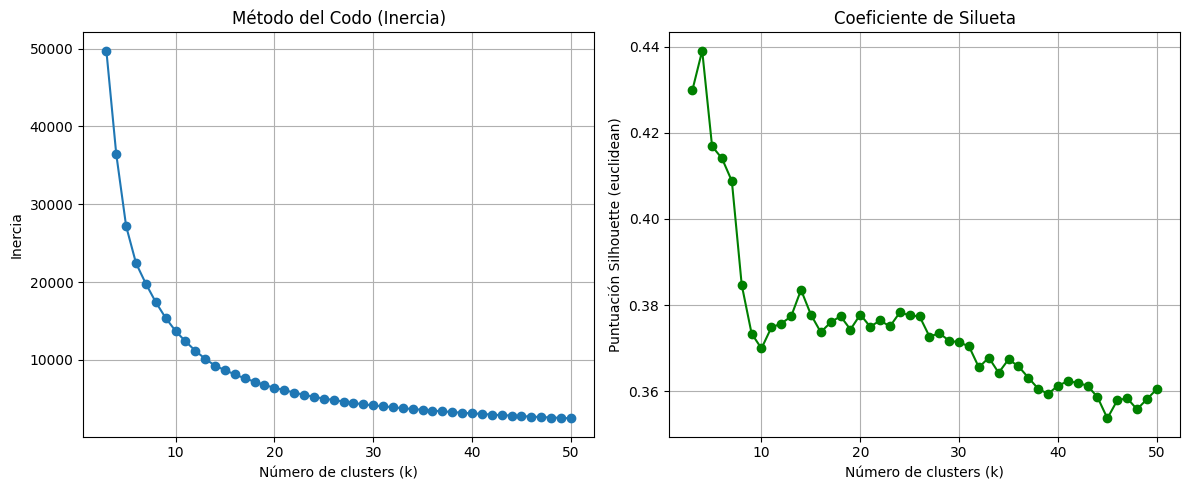

In [68]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Datos de entrada ---
X = ingredientes_umap.values  # tu proyección UMAP 2D

# --- Rango de valores de k ---
k_values = range(3, 51)

inertias = []       # Para el método del codo
silhouettes = []    # Para el coeficiente de silueta

print("⏳ Probando valores de k entre 3 y 50...\n")

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X)
    
    inertias.append(kmeans.inertia_)
    
    # Silhouette solo si hay más de un cluster
    if len(set(labels)) > 1:
        sil = silhouette_score(X, labels, metric="euclidean")
    else:
        sil = np.nan
    silhouettes.append(sil)
    
    print(f"k={k:2d} | Inercia={kmeans.inertia_:.2f} | Silhouette={sil:.4f}")

# --- Determinar mejores k ---
best_k = k_values[np.nanargmax(silhouettes)]
second_best_k = k_values[np.argsort(silhouettes)[::-1][1]]

# --- Graficar resultados ---
plt.figure(figsize=(12, 5))

# Método del Codo
plt.subplot(1, 2, 1)
plt.plot(k_values, inertias, marker="o")
plt.title("Método del Codo (Inercia)")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.grid(True)

# Coeficiente de Silueta
plt.subplot(1, 2, 2)
plt.plot(k_values, silhouettes, marker="o", color="green")
plt.title("Coeficiente de Silueta")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Puntuación Silhouette (euclidean)")
plt.grid(True)

plt.tight_layout()
plt.show()


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Visualiza el conjunto de datos original (la proyección 2D obtenida con <code>UMAP</code>) 
    coloreando cada punto según el <strong>cluster</strong> al que pertenece. 
</div>

✅ Clusters detectados: 14

Distribución de tamaños de cluster:
cluster_ingredientes
0     2320
1     1893
2     2305
3     2452
4     1911
5     1852
6     1641
7     1801
8     2781
9     2162
10    2454
11    1819
12    2192
13    2417
Name: count, dtype: int64


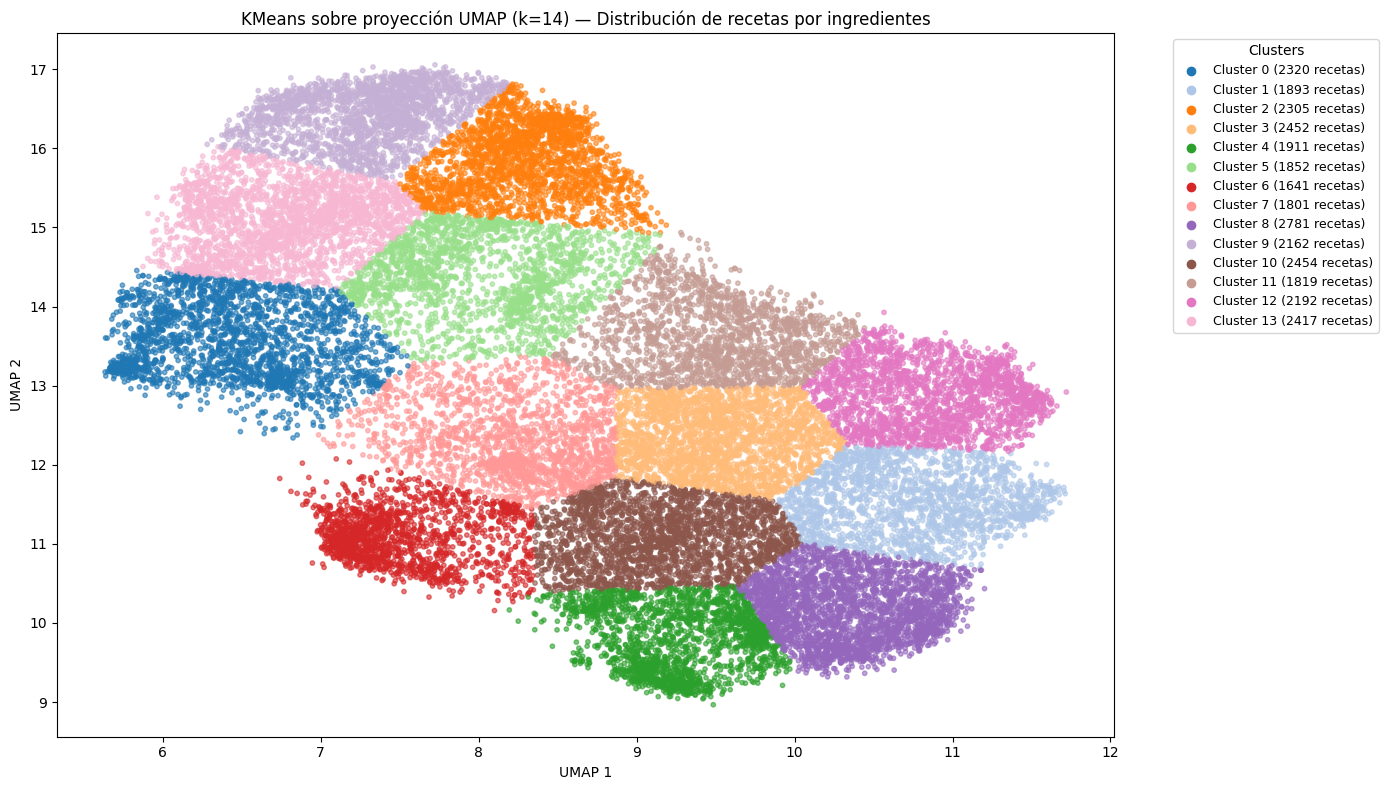

In [70]:


# --- Entrenar modelo KMeans ---
k = 14
kmeans_final = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)
labels_kmeans = kmeans_final.fit_predict(ingredientes_umap.values)

# --- Añadir etiquetas al DataFrame original ---
df_onehot["cluster_ingredientes"] = labels_kmeans

# --- Estadísticas básicas ---
cluster_counts = df_onehot["cluster_ingredientes"].value_counts().sort_index()
print(f"✅ Clusters detectados: {len(cluster_counts)}")
print("\nDistribución de tamaños de cluster:")
print(cluster_counts)

# --- Crear paleta de colores ---
palette = sns.color_palette("tab20", n_colors=k)

# --- Visualización ---
plt.figure(figsize=(14, 8))
plt.scatter(
    ingredientes_umap["UMAP_1"],
    ingredientes_umap["UMAP_2"],
    c=[palette[label % len(palette)] for label in labels_kmeans],
    s=10, alpha=0.6
)

plt.title(f"KMeans sobre proyección UMAP (k={k}) — Distribución de recetas por ingredientes")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

# Leyenda (clusters principales)
for label in sorted(cluster_counts.index):
    color = palette[label % len(palette)]
    plt.scatter([], [], c=[color], label=f"Cluster {label} ({cluster_counts[label]} recetas)")

plt.legend(
    title="Clusters",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=True,
    fontsize=9
)

plt.tight_layout()
plt.show()



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


✅ Clusters detectados (sin ruido): 348
🚫 Puntos clasificados como ruido: 13064

Distribución de tamaños de cluster:
cluster_ingredientes
-1      13064
 0         28
 1         22
 2         36
 3         53
        ...  
 343       77
 344       85
 345       23
 346       55
 347      106
Name: count, Length: 349, dtype: int64


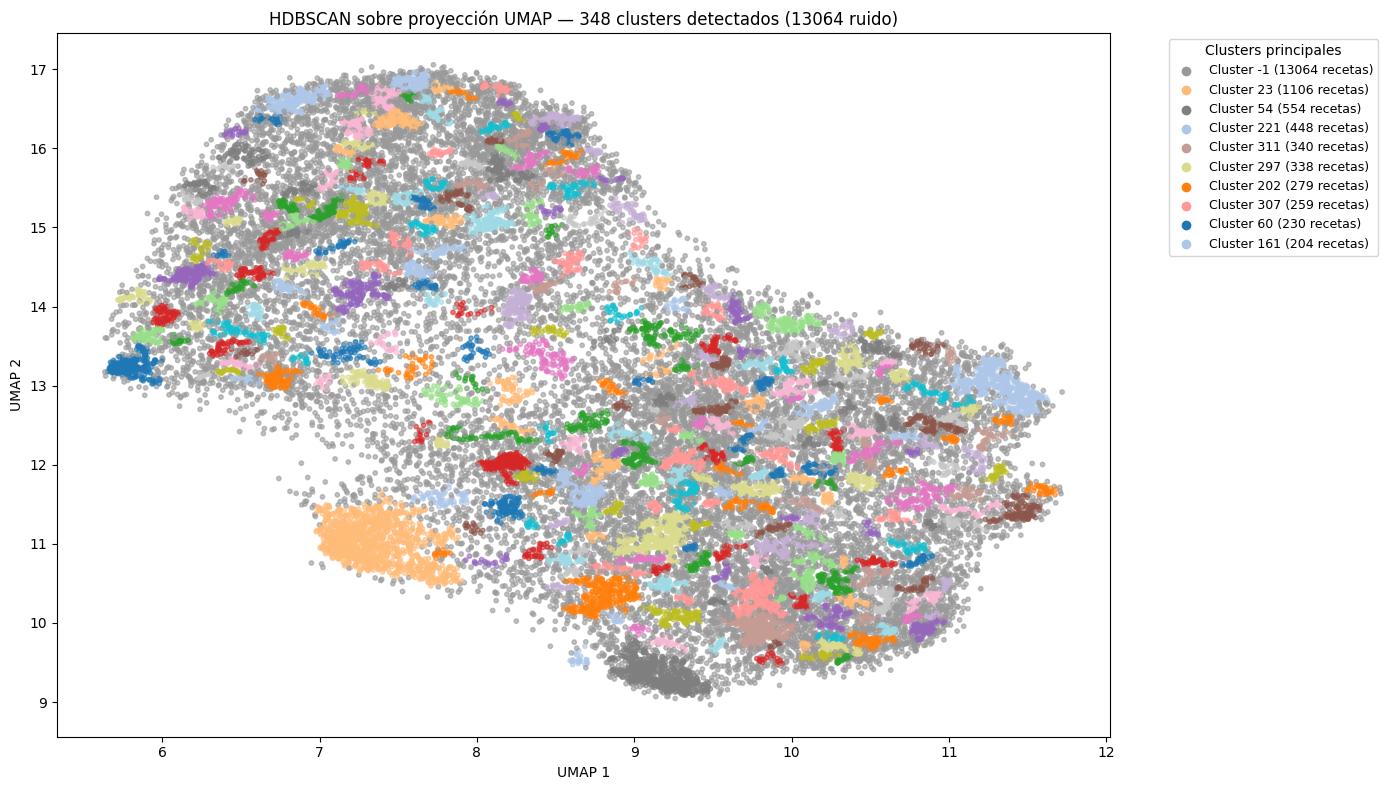

In [82]:
import hdbscan
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Entrenar modelo HDBSCAN ---
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,      # tamaño mínimo de cluster
    min_samples=5,            # sensibilidad al ruido
    metric="euclidean",       # correcto aquí porque UMAP ya usó Jaccard
    cluster_selection_method="eom",
    core_dist_n_jobs=-1
)

labels_hdb = clusterer.fit_predict(ingredientes_umap.values)

# --- Añadir etiquetas al DataFrame original ---
df_onehot["cluster_ingredientes"] = labels_hdb

# --- Estadísticas básicas ---
n_clusters = len(set(labels_hdb)) - (1 if -1 in labels_hdb else 0)
n_noise = np.sum(labels_hdb == -1)
cluster_counts = df_onehot["cluster_ingredientes"].value_counts().sort_index()

print(f"✅ Clusters detectados (sin ruido): {n_clusters}")
print(f"🚫 Puntos clasificados como ruido: {n_noise}")
print("\nDistribución de tamaños de cluster:")
print(cluster_counts)

# --- Crear paleta de colores ---
palette = sns.color_palette("tab20", n_colors=max(1, n_clusters))

# --- Visualización ---
plt.figure(figsize=(14, 8))
plt.scatter(
    ingredientes_umap["UMAP_1"],
    ingredientes_umap["UMAP_2"],
    c=[
        palette[label % len(palette)] if label >= 0 else (0.6, 0.6, 0.6)
        for label in labels_hdb
    ],
    s=10, alpha=0.6
)

plt.title(f"HDBSCAN sobre proyección UMAP — {n_clusters} clusters detectados ({n_noise} ruido)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

# --- Leyenda (solo los clusters principales) ---
cluster_sizes = pd.Series(labels_hdb).value_counts()
top_clusters = cluster_sizes.head(10).index
for label in top_clusters:
    color = (0.6, 0.6, 0.6) if label == -1 else palette[label % len(palette)]
    plt.scatter([], [], c=[color], label=f"Cluster {label} ({cluster_sizes[label]} recetas)")

plt.legend(
    title="Clusters principales",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=True,
    fontsize=9
)

plt.tight_layout()
plt.show()


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Para interpretar el clustering y comprobar su coherencia, selecciona los <strong>10 clusters</strong> más grandes y muestra, para cada uno:
  <ol>
    <li>
      Las <strong>5 recetas más cercanas al centroide</strong> del cluster (si el método lo define). 
      Si no hay centroide, usa el <em>centroide empírico</em> (media del vector del cluster) o el <em>medoide</em> 
      (receta con menor distancia media al resto). Emplea una métrica adecuada a la representación.
    </li>
    <li>
      También, para cada cluster, muestra los <strong>ingredientes más repetidos</strong> del cluster (por ejemplo, top-3 o top-5), opcionalmente puedes indicar su frecuencia relativa
      para caracterizar el “tema” del grupo. Puedes agrupar y contar con utilidades tipo 
      <code>Counter</code> o transformaciones previas del one-hot.
    </li>
  </ol>
</div>

In [83]:
from sklearn.metrics.pairwise import cosine_distances
from collections import Counter
import numpy as np
import pandas as pd

# --- Variables base ---
labels = df_onehot["cluster_ingredientes"]
X_umap = ingredientes_umap.values  # representación UMAP usada en KMeans
X_onehot = ingredientes_df         # matriz original binaria de ingredientes

# --- Seleccionar los 10 clusters más grandes ---
top_clusters = labels.value_counts().head(10).index
print(f"✅ Top {len(top_clusters)} clusters más grandes:", list(top_clusters))

# --- Diccionario para guardar resultados ---
representantes = {}

for cluster_id in top_clusters:
    # 1️⃣ Extraer índices del cluster
    idx_cluster = df_onehot[df_onehot["cluster_ingredientes"] == cluster_id].index
    emb_cluster = X_umap[idx_cluster]

    # 2️⃣ Calcular centroide del cluster (KMeans ya tiene centroides, pero por si acaso)
    centroide = emb_cluster.mean(axis=0).reshape(1, -1)

    # 3️⃣ Calcular distancias coseno al centroide
    distancias = cosine_distances(centroide, emb_cluster)[0]

    # 4️⃣ Seleccionar las 5 recetas más cercanas al centroide
    top5_idx = idx_cluster[np.argsort(distancias)[:5]]

    # 5️⃣ Calcular los ingredientes más frecuentes dentro del cluster
    ingredientes_cluster = X_onehot.loc[idx_cluster]
    suma_ingredientes = ingredientes_cluster.sum().sort_values(ascending=False)
    top_ingredientes = suma_ingredientes.head(5)
    top_ingredientes_rel = (top_ingredientes / len(idx_cluster)).round(3)

    # 6️⃣ Guardar resultados
    representantes[cluster_id] = {
        "recetas": df_onehot.loc[top5_idx, ["name", "description"]],
        "ingredientes": top_ingredientes_rel
    }

# --- Mostrar resultados ---
for cluster_id, data in representantes.items():
    recetas = data["recetas"]
    top_ing = data["ingredientes"]

    print(f"\n🍳 Cluster {cluster_id} — {len(df_onehot[df_onehot['cluster_ingredientes'] == cluster_id])} recetas")
    print("-" * 80)
    
    print("🔹 Ingredientes más frecuentes:")
    for ing, freq in top_ing.items():
        print(f"   • {ing}: {freq*100:.1f}% de las recetas")

    print("\n🔸 Recetas más representativas:")
    for _, row in recetas.iterrows():
        nombre = str(row["name"])[:60]
        desc = str(row["description"])[:150].replace("\n", " ")
        print(f"   • {nombre}: {desc}...")


✅ Top 10 clusters más grandes: [-1, 23, 54, 221, 311, 297, 202, 307, 60, 161]

🍳 Cluster -1 — 13064 recetas
--------------------------------------------------------------------------------
🔹 Ingredientes más frecuentes:
   • salt: 37.7% de las recetas
   • butter: 25.4% de las recetas
   • sugar: 20.2% de las recetas
   • eggs: 17.5% de las recetas
   • onion: 16.5% de las recetas

🔸 Recetas más representativas:
   • Rita Diablo: This is my own invention based on a spicy cocktail that Stephan Pyles, my culinary idol, serves in his restaurant.  You will need to garnish the drink...
   • Ortega Chili Cheese Casserole: This is what my Grandma served every year for Christmas brunch.  It is very rich but you can add more eggs if you'd like to tame it down or make it fl...
   • Vidalia Sweet Onion Bread: I found this recipe in the Las Vegas Review Journal.The Zelzah Shriners are bringing 40,000 lbs. of onions to LV to sell. This was one of the recipes ...
   • Barbecued Corn: A great side di

In [84]:
from sklearn.metrics.pairwise import cosine_distances
import numpy as np
import pandas as pd

# --- Variables base ---
labels = df_onehot["cluster_ingredientes"]
X_umap = ingredientes_umap.values      # representación UMAP 2D o N-D
X_onehot = ingredientes_df             # matriz one-hot original de ingredientes

# --- Excluir ruido (-1) y seleccionar los 10 clusters más grandes ---
top_clusters = labels[labels != -1].value_counts().head(10).index
print(f"✅ Top {len(top_clusters)} clusters más grandes:", list(top_clusters))

# --- Diccionario para guardar resultados ---
representantes = {}

for cluster_id in top_clusters:
    # 1️⃣ Extraer índices del cluster
    idx_cluster = df_onehot[df_onehot["cluster_ingredientes"] == cluster_id].index
    emb_cluster = X_umap[idx_cluster]

    # 2️⃣ Calcular centroide empírico (media de los puntos del cluster)
    centroide = emb_cluster.mean(axis=0).reshape(1, -1)

    # 3️⃣ Calcular distancias coseno al centroide
    distancias = cosine_distances(centroide, emb_cluster)[0]

    # 4️⃣ Seleccionar las 5 recetas más cercanas al centroide (representativas)
    top5_idx = idx_cluster[np.argsort(distancias)[:5]]

    # 5️⃣ Calcular los ingredientes más frecuentes dentro del cluster
    ingredientes_cluster = X_onehot.loc[idx_cluster]
    suma_ingredientes = ingredientes_cluster.sum().sort_values(ascending=False)
    top_ingredientes = suma_ingredientes.head(5)
    top_ingredientes_rel = (top_ingredientes / len(idx_cluster)).round(3)

    # 6️⃣ Guardar resultados
    representantes[cluster_id] = {
        "recetas": df_onehot.loc[top5_idx, ["name", "description"]],
        "ingredientes": top_ingredientes_rel
    }

# --- Mostrar resultados ---
for cluster_id, data in representantes.items():
    recetas = data["recetas"]
    top_ing = data["ingredientes"]

    print(f"\n🍳 Cluster {cluster_id} — {len(df_onehot[df_onehot['cluster_ingredientes'] == cluster_id])} recetas")
    print("-" * 80)
    
    print("🔹 Ingredientes más frecuentes:")
    for ing, freq in top_ing.items():
        print(f"   • {ing}: {freq*100:.1f}% de las recetas")

    print("\n🔸 Recetas más representativas:")
    for _, row in recetas.iterrows():
        nombre = str(row["name"])[:60]
        desc = str(row["description"])[:150].replace("\n", " ")
        print(f"   • {nombre}: {desc}...")


✅ Top 10 clusters más grandes: [23, 54, 221, 311, 297, 202, 307, 60, 161, 326]

🍳 Cluster 23 — 1106 recetas
--------------------------------------------------------------------------------
🔹 Ingredientes más frecuentes:
   • soy sauce: 61.8% de las recetas
   • sesame oil: 26.9% de las recetas
   • garlic cloves: 26.5% de las recetas
   • fresh ginger: 23.4% de las recetas
   • vegetable oil: 22.2% de las recetas

🔸 Recetas más representativas:
   • Szechuan Vegetable Stir-Fry: From Whole Health M.D. I made this for my family, none of whom is a vegetarian, and they all loved it. Great Asian flavors....
 Serve the wontons in a mild, low... A vegan adaptation of a Cantonese-American favorite.  Not hard to make but takes some time to stuff the wontons.  
   • Pomegranate Juice Reduction Sauce: This is a yummy tangy sauce that I adapted from a Wolfgang Puck recipe using pork, but it can also be used for chicken or beef, or as a marinade....
   • Dark Side Salad: Black kale, black garlic, b

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Analiza los resultados del clustering y valora si los <strong>clusters obtenidos tienen sentido</strong> 
    desde un punto de vista culinario. Observa los ingredientes más frecuentes y las recetas prototipo 
    de cada grupo, e identifica si existe un patrón claro que relacione los platos entre sí.
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Compara los resultados obtenidos en este apartado (basados en la representación <strong>one-hot de ingredientes</strong>)
    con los del primer apartado (embeddings semánticos generados con <strong>MiniLM</strong>).
    Analiza si los grupos que aparecen son similares o diferentes, reflexiona sobre cómo influye el tipo de representación y explica las principales diferencias observadas.
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Reflexiona sobre los posibles <strong>casos de uso</strong> de los dos enfoques de clustering aplicados:
  <ul>
    <li>
      ¿Para qué tipo de problema o aplicación sería más útil el clustering basado en los 
      <strong>embeddings semánticos</strong> (MiniLM)?
    </li>
    <li>
      ¿Y en qué tipo de situación resultaría más adecuado el clustering obtenido con la 
      <strong>representación one-hot de ingredientes</strong>?
    </li>
  </ul>
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Piensa en <strong>otras maneras de generar una representación</strong> de las recetas, distintas de las vistas en la práctica 
    (como los embeddings semánticos o los vectores one-hot de ingredientes). 
    Describe brevemente cómo construirías esa nueva representación y qué tipo de información capturaría.
</div>